In [1]:
from scipy.io import arff
import pandas as pd

# Load the EigenWorms dataset from ARFF files, which are in Latin-1 encoding
with open('EigenWorms_TRAIN.arff', 'r', encoding='latin1') as f:
    data_train, meta_train = arff.loadarff(f)
with open('EigenWorms_TEST.arff', 'r', encoding='latin1') as f:
    data_test, meta_test = arff.loadarff(f)

df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)

# Concatenate the training and test dataframes
df_all = pd.concat([df_train, df_test], ignore_index=True)

In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   eigenWormMultivariate_attribute  259 non-null    object
 1   target                           259 non-null    object
dtypes: object(2)
memory usage: 4.2+ KB


In [ ]:
df_all['target'].unique()

array([b'1', b'2', b'3', b'4', b'5'], dtype=object)

In [ ]:
# No missing values in the dataset

In [ ]:
df_all.head()

,eigenWormMultivariate_attribute,target
0,"[[-0.869467, -0.759418, -0.703444, -0.5848, -0...",b'1'
1,"[[-1.943972, -1.945142, -1.954392, -2.018798, ...",b'1'
2,"[[1.618473, 1.669408, 1.706154, 1.680708, 1.61...",b'1'
3,"[[-0.877703, -0.825706, -0.763933, -0.671876, ...",b'1'
4,"[[2.238256, 2.200505, 2.148145, 2.224002, 2.18...",b'1'


In [ ]:
print(type(df_all['eigenWormMultivariate_attribute'][0]))
print(df_all['eigenWormMultivariate_attribute'][0].shape)
print(type(df_all['eigenWormMultivariate_attribute'][0][0]))
print(df_all['eigenWormMultivariate_attribute'][0])
print(df_all['eigenWormMultivariate_attribute'].shape)

<class 'numpy.ndarray'>
(6,)
<class 'numpy.void'>
[(-0.869467, -0.759418, -0.703444, -0.5848  , -0.355616, 0.109357, 0.144901, 0.371266, 0.567943, 0.756942, 1.010056,  1.033913,  1.2025  ,  1.36947 , 1.750441, 1.876057, 2.140111,  2.433293,  2.368573,  2.579087,  2.7896  ,  3.000114,  3.210628,  3.421142,  3.631655,  3.569162,  3.684875,  3.826309,  3.938216,  3.863386,  3.883884,  3.845366,  3.913643,  3.820544,  3.753358,  3.703248,  3.73515 ,  3.533301,  3.440252,  3.392087,  3.338258,  3.152287,  3.00383 ,  3.014552,  2.848362,  2.682172,  2.515983,  2.349793,  2.183604,  2.017414,  2.011531,  1.943383,  1.8134  ,  1.827581,  1.844279,  1.640946,  1.576312,  1.285295,  1.097716,  0.924735,  0.714172,  0.208919,  0.209072,  0.046326,  0.022187, -0.174097, -0.231654, -0.124389, -0.245599, -0.206185, -0.162151, -0.160895, -0.142275, -0.243643, -0.296545, -0.315168, -0.347158, -0.386633, -0.319541, -0.224982, -0.077965,  0.175339,  0.488072,  0.903462,  1.155364,  1.422164,  1.558867, 

In [ ]:
print(df_all['eigenWormMultivariate_attribute'][0][0].dtype.names)

('att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'att13', 'att14', 'att15', 'att16', 'att17', 'att18', 'att19', 'att20', 'att21', 'att22', 'att23', 'att24', 'att25', 'att26', 'att27', 'att28', 'att29', 'att30', 'att31', 'att32', 'att33', 'att34', 'att35', 'att36', 'att37', 'att38', 'att39', 'att40', 'att41', 'att42', 'att43', 'att44', 'att45', 'att46', 'att47', 'att48', 'att49', 'att50', 'att51', 'att52', 'att53', 'att54', 'att55', 'att56', 'att57', 'att58', 'att59', 'att60', 'att61', 'att62', 'att63', 'att64', 'att65', 'att66', 'att67', 'att68', 'att69', 'att70', 'att71', 'att72', 'att73', 'att74', 'att75', 'att76', 'att77', 'att78', 'att79', 'att80', 'att81', 'att82', 'att83', 'att84', 'att85', 'att86', 'att87', 'att88', 'att89', 'att90', 'att91', 'att92', 'att93', 'att94', 'att95', 'att96', 'att97', 'att98', 'att99', 'att100', 'att101', 'att102', 'att103', 'att104', 'att105', 'att106', 'att107', 'att108', 'att109', 'att110', 'att111

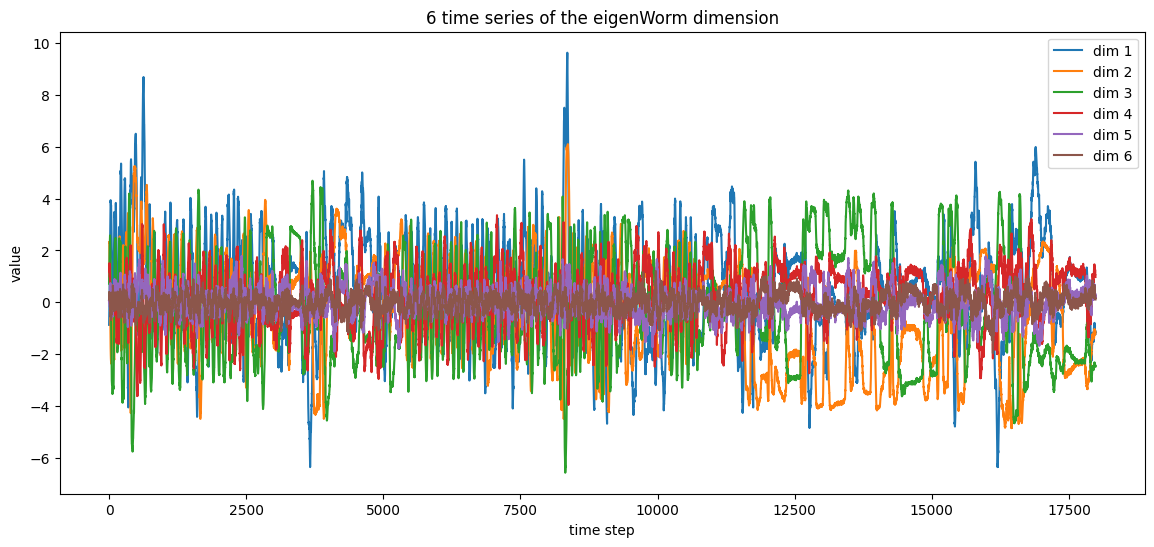

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Get one row (one experiment): all time series are in this row
row = df_all['eigenWormMultivariate_attribute'].iloc[0]

# Get the field names (the time steps)
time_steps = row[0].dtype.names

n_dims = 6
n_times = len(time_steps)

# Build the 6 time series
series_by_dim = []

for d in range(n_dims):
    # Extract the full time series for dimension d
    series = np.array([row[d][t] for t in time_steps])
    series_by_dim.append(series)

# Plot
plt.figure(figsize=(14, 6))
for d in range(n_dims):
    plt.plot(series_by_dim[d], label=f'dim {d+1}')
plt.legend()
plt.xlabel('time step')
plt.ylabel('value')
plt.title('6 time series of the eigenWorm dimension')
plt.show()

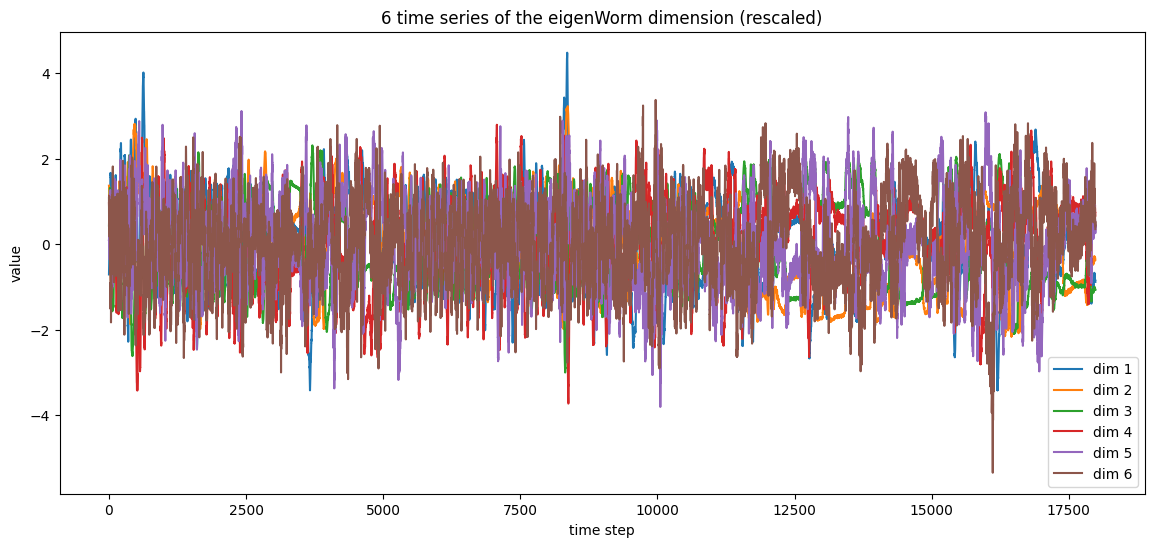

In [3]:
# We want to rescale the dimensions to have the same scale
from sklearn.preprocessing import StandardScaler
# Rescale each dimension to have mean 0 and std 1
scalers = [StandardScaler() for _ in range(n_dims)]
for d in range(n_dims):
    series_by_dim[d] = scalers[d].fit_transform(series_by_dim[d].reshape(-1, 1)).flatten()
# Plot the rescaled series
plt.figure(figsize=(14, 6))
for d in range(n_dims):
    plt.plot(series_by_dim[d], label=f'dim {d+1}')
plt.legend()
plt.xlabel('time step')
plt.ylabel('value')
plt.title('6 time series of the eigenWorm dimension (rescaled)')
plt.show()

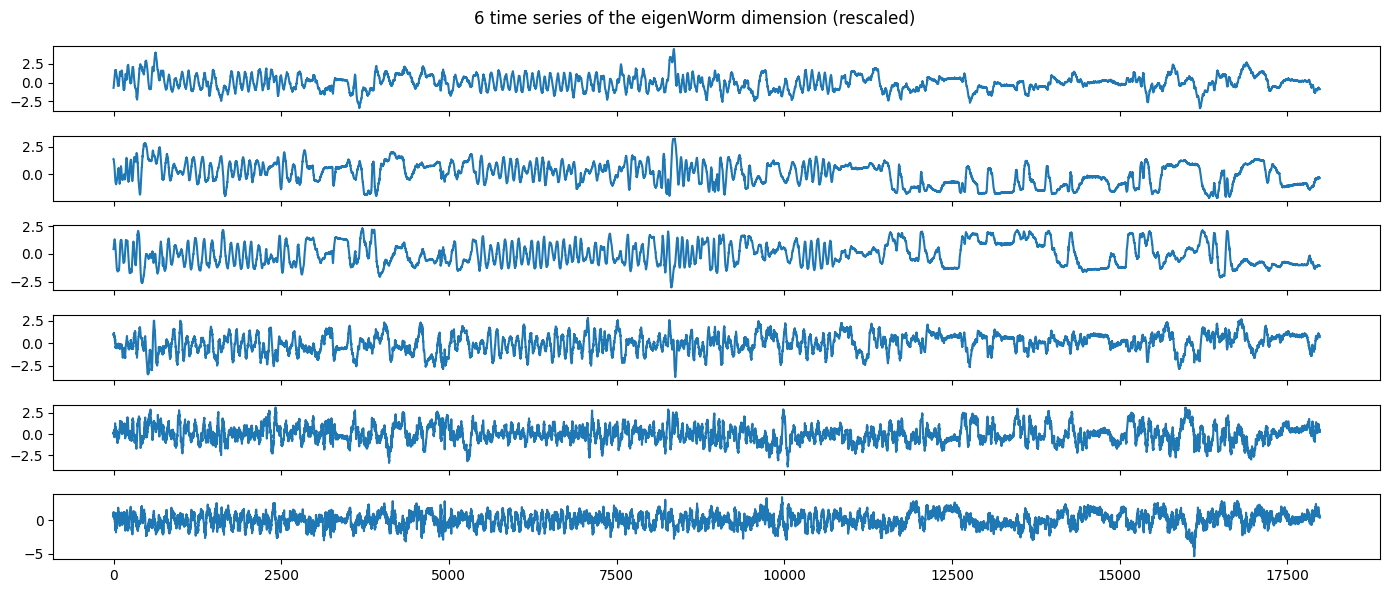

In [ ]:
# Finally we decide to plot each dimension in a separate subplot
fig, axs = plt.subplots(n_dims, 1, figsize=(14, 6), sharex=True)
for d in range(n_dims):
    axs[d].plot(series_by_dim[d])
plt.suptitle('6 time series of the eigenWorm dimension (rescaled)')
plt.tight_layout()
plt.show()

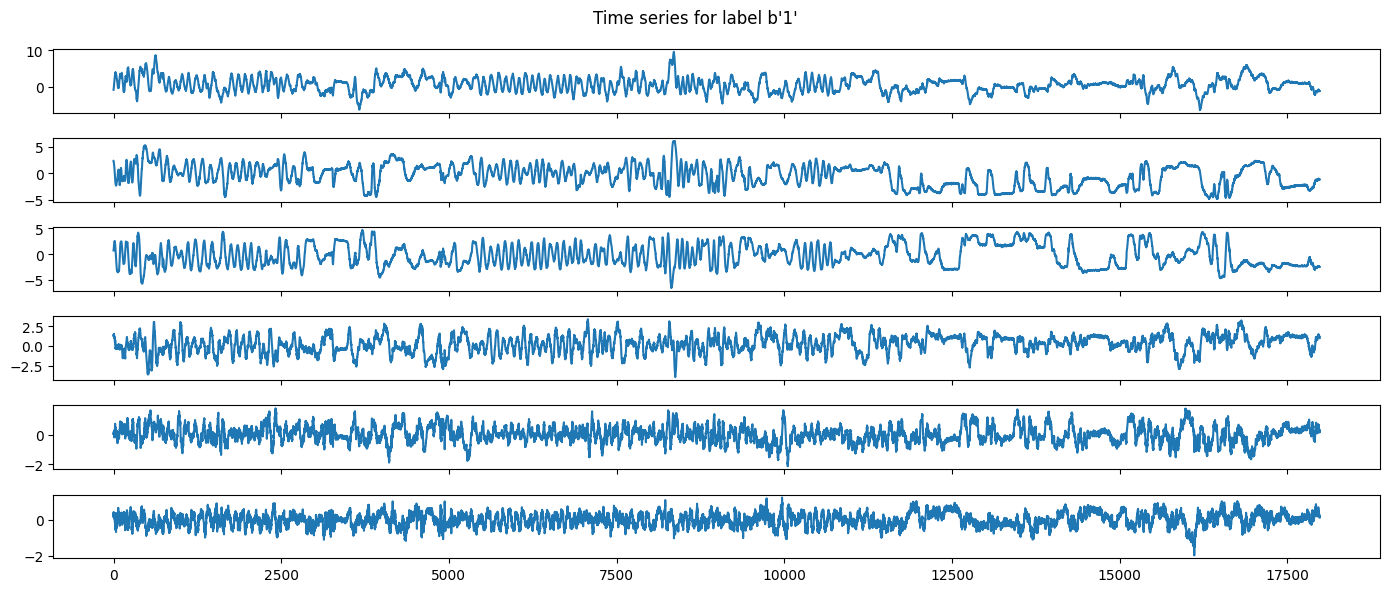

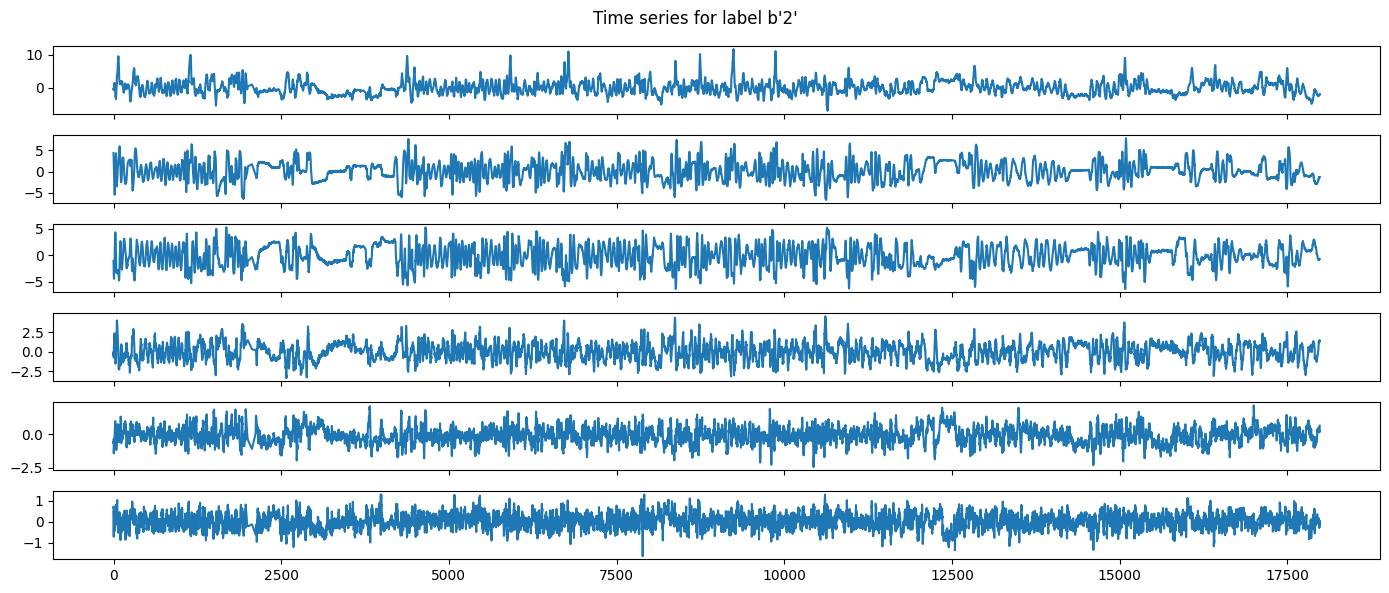

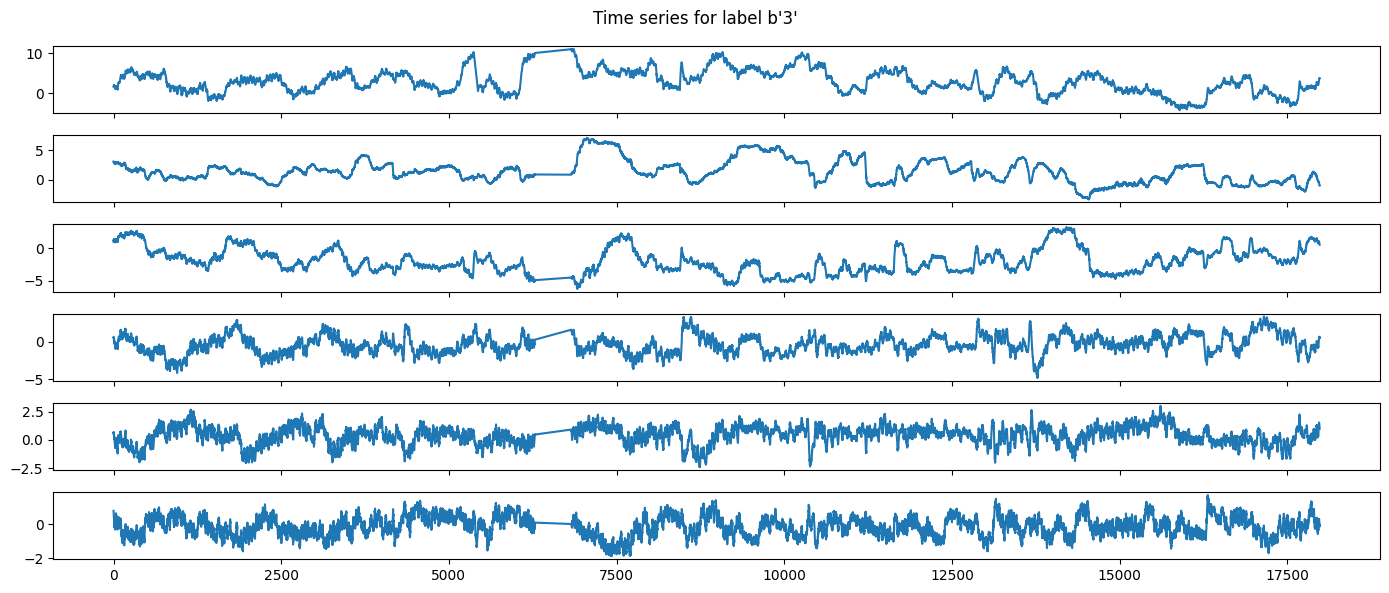

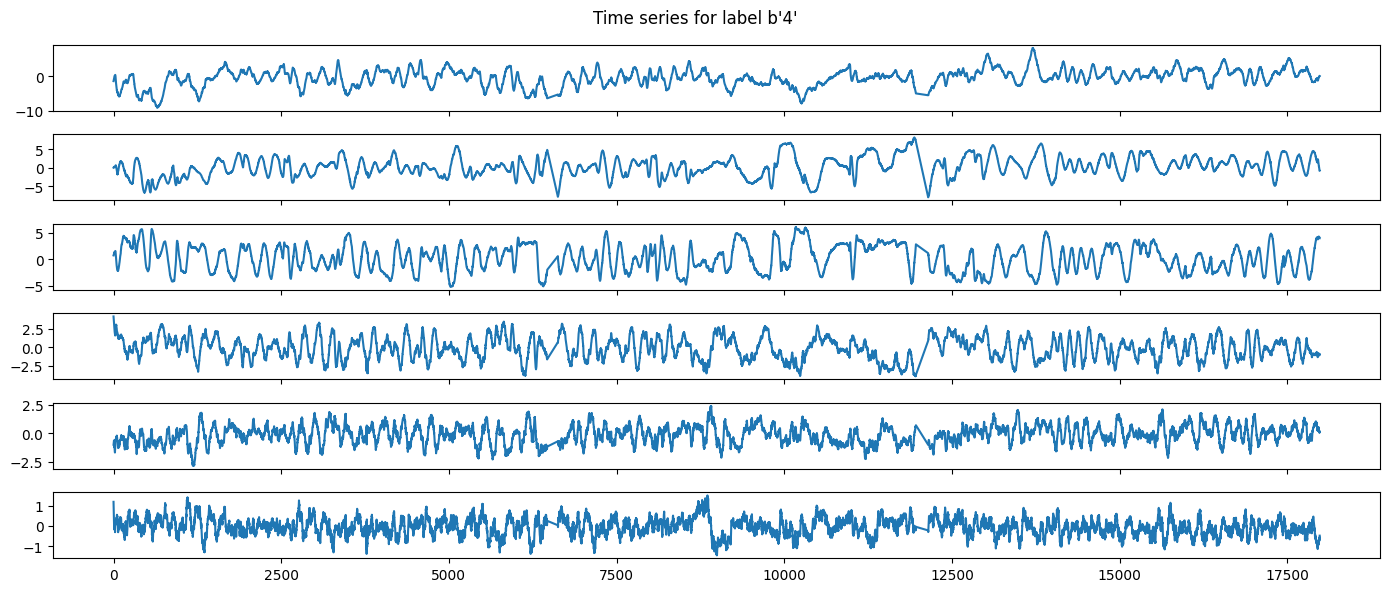

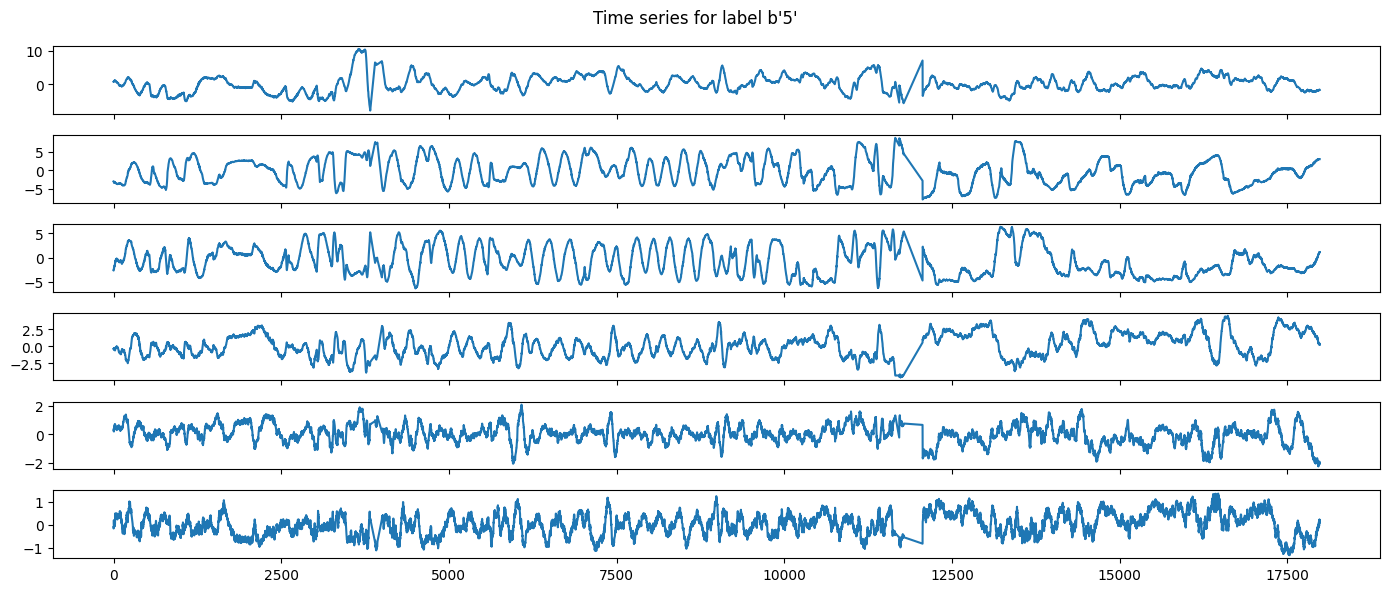

In [ ]:
# Get unique labels
unique_labels = df_all['target'].unique()

for label in unique_labels:

    rows_with_label = df_all[df_all['target'] == label]['eigenWormMultivariate_attribute']
    row = rows_with_label.iloc[0]
    time_steps = row[0].dtype.names

    # Build time series for each dimension
    n_dims = 6
    series_by_dim = []

    for d in range(n_dims):
        series = np.array([row[d][t] for t in time_steps])
        series_by_dim.append(series)

    # Plot
    fig, axs = plt.subplots(n_dims, 1, figsize=(14, 6), sharex=True)
    for d in range(n_dims):
        axs[d].plot(series_by_dim[d])
    plt.suptitle(f'Time series for label {label}')
    plt.tight_layout()
    plt.show()

In [4]:
# Convert the 'eigenWormMultivariate_attribute' to an array of shape (n_samples, n_time_steps, n_dims)
import numpy as np

n_samples = len(df_all)
n_dims = 6

time_steps = df_all['eigenWormMultivariate_attribute'].iloc[0][0].dtype.names
n_timesteps = len(time_steps)

# Initialize the final array
X = np.zeros((n_samples, n_timesteps, n_dims), dtype=np.float32)

for i in range(n_samples):
    row = df_all['eigenWormMultivariate_attribute'].iloc[i]
    for d in range(n_dims):
        X[i, :, d] = [row[d][t] for t in time_steps]


y = df_all['target'].values

In [5]:
from sklearn.preprocessing import StandardScaler

n_samples, n_timesteps, n_dims = X.shape
X_scaled = np.zeros_like(X)

for d in range(n_dims):
    scaler = StandardScaler()
    X_2d = X[:, :, d].reshape(-1, 1)
    X_scaled[:, :, d] = scaler.fit_transform(X_2d).reshape(n_samples, n_timesteps)

In [ ]:
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Shape of X: (259, 17984, 6), Shape of y: (259,)


In [ ]:
print(y[:100])

[b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1'
 b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1'
 b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1'
 b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'1' b'2'
 b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'2'
 b'2' b'2' b'2' b'2' b'2' b'2' b'2' b'3' b'3' b'3' b'3' b'3' b'3' b'3'
 b'3' b'3' b'3' b'3' b'3' b'3' b'3' b'3' b'3' b'3' b'4' b'4' b'4' b'4'
 b'4' b'4']


In [6]:
# Shuffle the dataset to avoid any order bias
from sklearn.utils import shuffle

X, y = shuffle(X_scaled, y, random_state=42)

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.dtype)
print(y_train.dtype)

float32
int64


In [ ]:
np.bincount(y_train)

array([88, 35, 27, 35, 22])

In [9]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to balance the dataset
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

In [ ]:
# First before diving into Deep Learning, we will try to use simple model as random forest and SVM.
# We first need to create discriminants features from the time series data.

# idea : for each dim : mean, std, min, max, median, energy, freq_dominant, autocorrelation (lag 1).
# rk : Not a lot of features so no need to use PCA or other dimensionality reduction techniques.

In [ ]:
from scipy.signal import periodogram

def extract_features(X):
    n_samples, _, n_dims = X.shape
    features = []
    for i in range(n_samples):
        feats = []
        for d in range(n_dims):
            series = X[i, :, d]
            # Basic
            feats.append(np.mean(series))
            feats.append(np.std(series))
            feats.append(np.min(series))
            feats.append(np.max(series))
            feats.append(np.median(series))
            # Energy
            feats.append(np.sum(series ** 2))
            # Dominant frequency
            freqs, psd = periodogram(series)
            dominant_freq = freqs[np.argmax(psd)] if len(psd) > 0 else 0
            feats.append(dominant_freq)
            # Autocorrelation (lag 1)
            if len(series) > 1:
                autocorr = np.corrcoef(series[:-1], series[1:])[0, 1]
            else:
                autocorr = 0
            feats.append(autocorr)
        features.append(feats)
    return np.array(features)

X_features_train = extract_features(X_train)
X_features_test = extract_features(X_test)

In [ ]:
# Classification with Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)
rf.fit(X_features_train, y_train)

# Evaluate the model
from sklearn.metrics import classification_report
y_pred = rf.predict(X_features_test)

# Convert byte strings to regular strings (debug)
target_names = [name.decode('utf-8') if isinstance(name, bytes) else name for name in le.classes_]

print(classification_report(y_test, y_pred, target_names=target_names))

# This classifier is very accurate.
# Let's plot the feature importances.

              precision    recall  f1-score   support

           1       0.91      0.95      0.93        22
           2       1.00      0.89      0.94         9
           3       1.00      1.00      1.00         8
           4       0.90      0.90      0.90        10
           5       0.67      0.67      0.67         3

    accuracy                           0.92        52
   macro avg       0.90      0.88      0.89        52
weighted avg       0.92      0.92      0.92        52



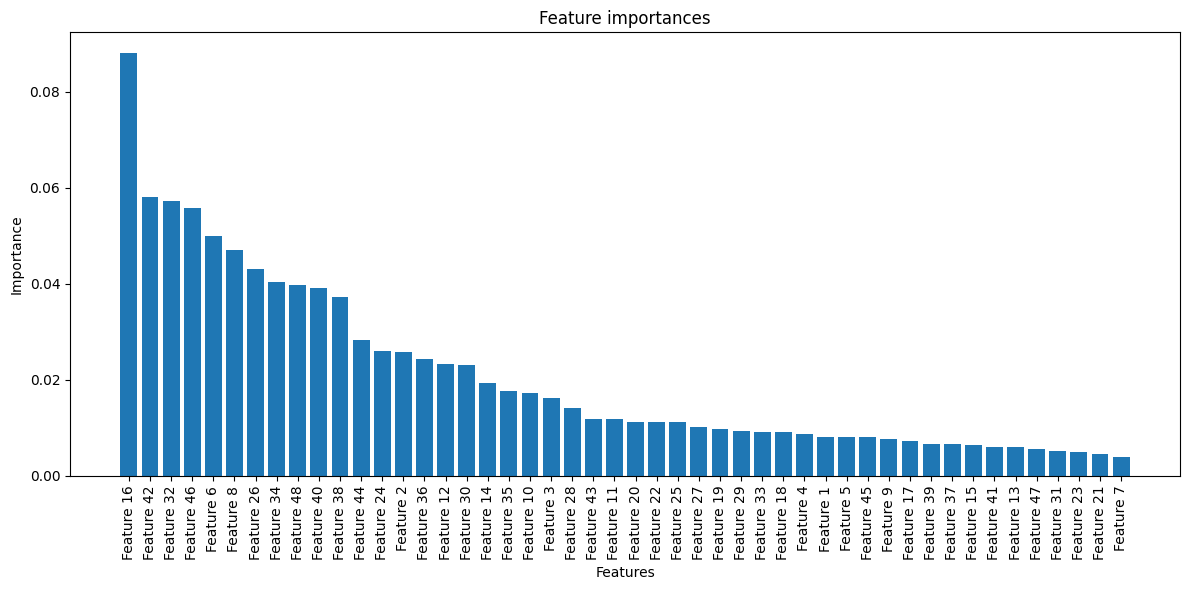

In [ ]:
# Feature importance (2nd task)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [f'Feature {i+1}' for i in indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# What is feature 16 ?
# It's the autocorrelation (lag 1) of the 2nd dimension

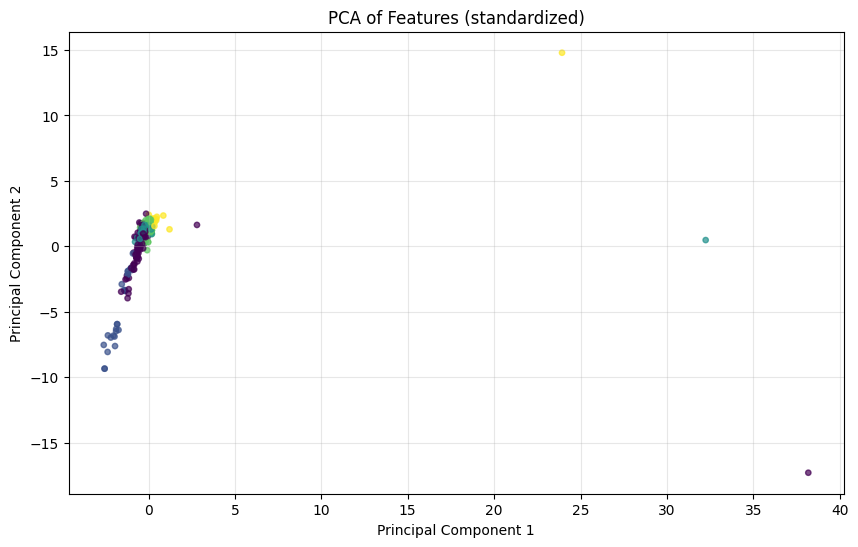

In [ ]:
# We can draw the principal plane of the PCA of the features
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_features_train_scaled = scaler.fit_transform(X_features_train)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features_train_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7, s=15)
plt.title('PCA of Features (standardized)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Classification with SVM
from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight=class_weight_dict, random_state=42)
svm.fit(X_features_train, y_train)

# Evaluate the SVM model
y_pred_svm = svm.predict(X_features_test)
print(classification_report(y_test, y_pred_svm, target_names=target_names))

# This classifier performs poorly and tends to predict the majority class. I tried different kernels (sigmoid, rbf, poly), but the results did not improve.

              precision    recall  f1-score   support

           1       0.42      1.00      0.59        22
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00         3

    accuracy                           0.42        52
   macro avg       0.08      0.20      0.12        52
weighted avg       0.18      0.42      0.25        52



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Now let's try deep learning to see if we can get better results

In [ ]:
# Let's implement early stopping to avoid overfitting; it will be very useful for the rest
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True
)

In [10]:
import tensorflow as tf

rnn = tf.keras.models.Sequential([
    tf.keras.layers.SimpleRNN(
        units=64,
        activation="tanh",
        return_sequences=False,
        kernel_initializer=tf.keras.initializers.Identity(gain=1.0),
        ),
    tf.keras.layers.Dense(units=5, activation="softmax")
])
rnn.build(input_shape=(None, 17984, 6))  # 17984 time steps, 6 dimensions
rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(
        clipnorm=1,
        learning_rate=0.0001),
        metrics=['accuracy']
        )
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,869 (19.02 KB)

 Trainable params: 4,869 (19.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = rnn.fit(X_train, y_train, validation_split=.3, epochs=100, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1591 - loss: 1.7710 - val_accuracy: 0.2381 - val_loss: 1.6063
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1821 - loss: 1.6678 - val_accuracy: 0.2698 - val_loss: 1.6037
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1492 - loss: 1.6679 - val_accuracy: 0.2698 - val_loss: 1.6022
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1714 - loss: 1.6744 - val_accuracy: 0.2381 - val_loss: 1.6007
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2018 - loss: 1.6669 - val_accuracy: 0.2698 - val_loss: 1.5994
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2134 - loss: 1.6797 - val_accuracy: 0.2698 - val_loss: 1.5984
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2721 - loss: 1.6555 - val_accuracy: 0.2857 - val_loss: 1.5976
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2186 - loss: 1.5770 - val_accuracy: 0.3333 - val_loss: 1.5966
Ep

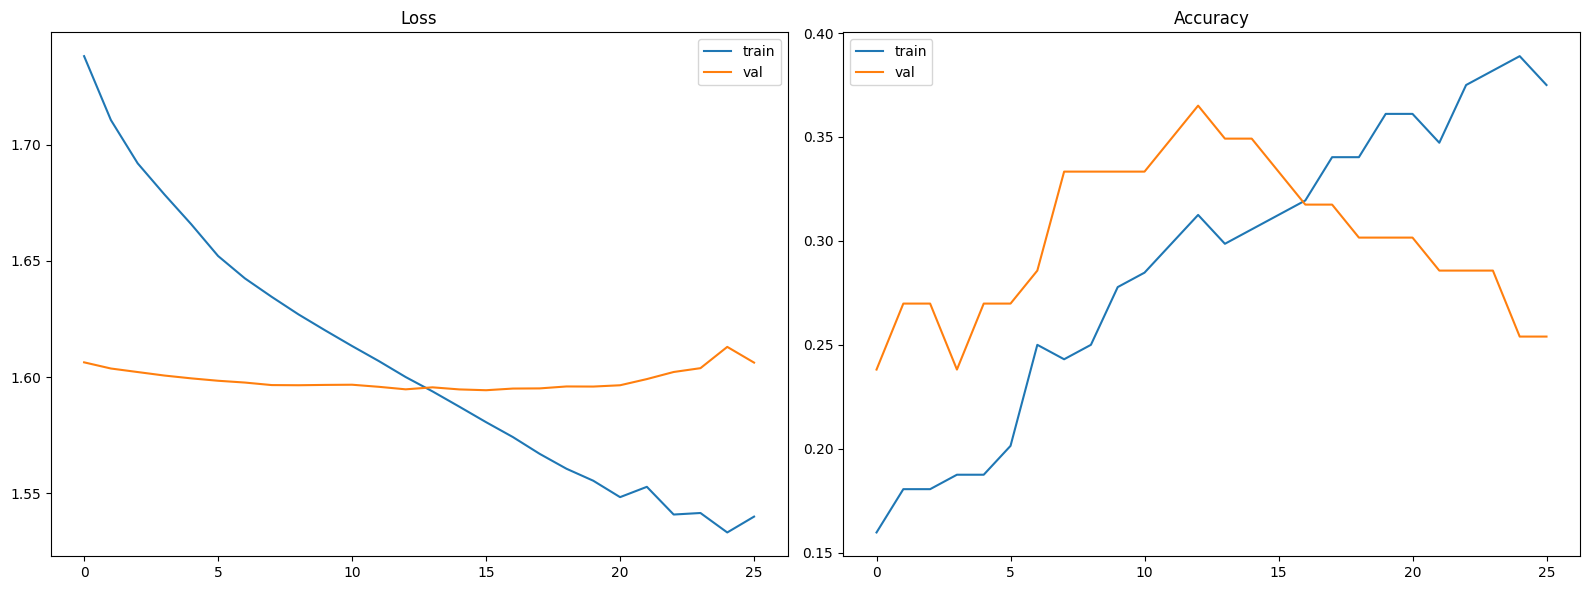

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
rnn.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2756 - loss: 1.6222


[1.616076946258545, 0.2884615361690521]

In [ ]:
# 2 layers of LSTM
lstm = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units=64, return_sequences=False),
    tf.keras.layers.Dense(units=5, activation="softmax")
])
lstm.build(input_shape=(None, 17984, 6)) # 17984 time steps, 6 dimensions
lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,501 (72.27 KB)

 Trainable params: 18,501 (72.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = lstm.fit(X_train, y_train, validation_split=.3, epochs=50, class_weight=class_weight_dict)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1942 - loss: 1.7893 - val_accuracy: 0.2857 - val_loss: 1.5990
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 628ms/step - accuracy: 0.1807 - loss: 1.5543 - val_accuracy: 0.2698 - val_loss: 1.6064
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 505ms/step - accuracy: 0.1871 - loss: 1.7244 - val_accuracy: 0.2698 - val_loss: 1.6177
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 579ms/step - accuracy: 0.2080 - loss: 1.7019 - val_accuracy: 0.2063 - val_loss: 1.6269
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 567ms/step - accuracy: 0.2405 - loss: 1.6406 - val_accuracy: 0.1587 - val_loss: 1.6382
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 603ms/step - accuracy: 0.2501 - loss: 1.5984 - val_accuracy: 0.1587 - val_loss: 1.6494
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 568ms/step - accuracy: 0.2334 - loss: 1.5877 - val_accuracy: 0.1587 - val_loss: 1.6663
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 567ms/step - accuracy: 0.2710 - loss: 1.5861 - val_accuracy: 0.1587 - val_loss: 1.

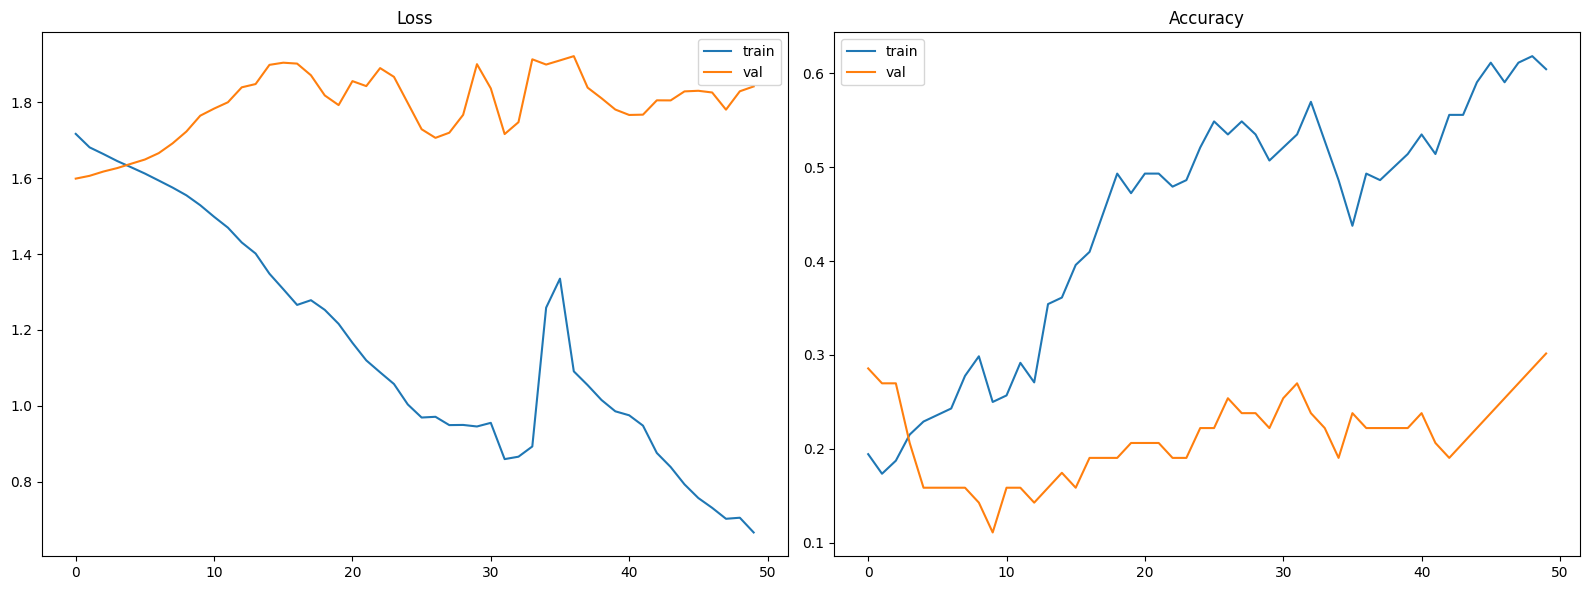

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lstm.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.2837 - loss: 1.9108


[1.9554661512374878, 0.26923078298568726]

In [ ]:
gru = tf.keras.models.Sequential([
    tf.keras.layers.GRU(64, kernel_initializer=tf.keras.initializers.Identity(gain=1.0)),
    tf.keras.layers.Dense(units=5, activation="softmax")
])
gru.build(input_shape=(None, 17984, 6))  # 17984 time steps, 6 dimensions
gru.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,149 (55.27 KB)

 Trainable params: 14,149 (55.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = gru.fit(X_train, y_train, validation_split=.3, epochs=500, class_weight=class_weight_dict)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 568ms/step - accuracy: 0.2231 - loss: 1.6511 - val_accuracy: 0.0794 - val_loss: 1.6165
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 620ms/step - accuracy: 0.2219 - loss: 1.6093 - val_accuracy: 0.0952 - val_loss: 1.6212
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 551ms/step - accuracy: 0.1869 - loss: 1.6492 - val_accuracy: 0.0794 - val_loss: 1.6285
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 487ms/step - accuracy: 0.1652 - loss: 1.6630 - val_accuracy: 0.0952 - val_loss: 1.6372
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 686ms/step - accuracy: 0.1975 - loss: 1.6187 - val_accuracy: 0.0952 - val_loss: 1.6455
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 495ms/step - accuracy: 0.1843 - loss: 1.5790 - val_accuracy: 0.0794 - val_loss: 1.6515
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.2135 - loss: 1.6877 - val_accuracy: 0.1111 - val_loss: 1.6602
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.2109 - loss: 1.6009 - val_accuracy: 0.0952 - v

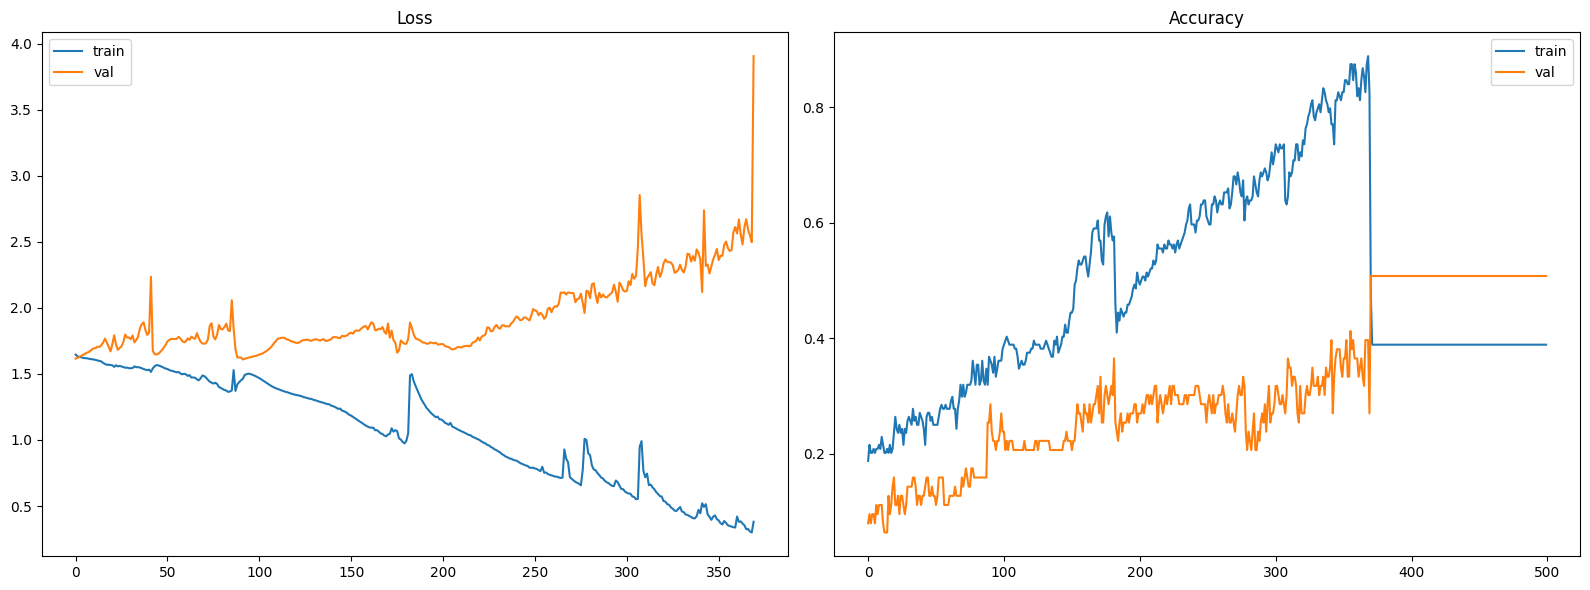

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
gru.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step - accuracy: 0.4071 - loss: nan


[nan, 0.42307692766189575]

In [ ]:
# The results are not very satisfactory; let's experiment with an encoder-decoder architecture instead.

In [ ]:
model = tf.keras.models.Sequential(
    [tf.keras.layers.LSTM(32, kernel_initializer=tf.keras.initializers.Identity(gain=1.0), return_sequences=True),
    tf.keras.layers.GRU(32, kernel_initializer=tf.keras.initializers.Identity(gain=1.0), return_sequences=False),
    tf.keras.layers.RepeatVector(1),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1, activation="linear"))]
    )
model.build(input_shape=(None, n_steps_in, 1))
model.compile(
    loss='mean_squared_error',
    optimizer="adam"
    )
model.summary()

In [ ]:
hist = model.fit(X_train, y_train, validation_split=.3, epochs=50, class_weight=class_weight_dict, callbacks=[early_stopping])

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

(207, 17984, 1)
(207,)
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3864 - loss: 1.6153 - val_accuracy: 0.5079 - val_loss: 1.5891
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 931ms/step - accuracy: 0.3890 - loss: 1.5896 - val_accuracy: 0.5079 - val_loss: 1.5676
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4220 - loss: 1.5638 - val_accuracy: 0.5079 - val_loss: 1.5403
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 986ms/step - accuracy: 0.3971 - loss: 1.5531 - val_accuracy: 0.5079 - val_loss: 1.5040
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 866ms/step - accuracy: 0.3902 - loss: 1.5277 - val_accuracy: 0.5079 - val_loss: 1.4574
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3815 - loss: 1.4996 - val_accuracy: 0.5079 - val_loss: 1.4065
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 934ms/step - accuracy: 0.4058 - loss: 1.4846 - val_accuracy: 0.5079 - val_loss: 1.3881
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 897ms/step - accuracy: 0.4097 - loss: 1.4752 - val_accuracy: 0.5

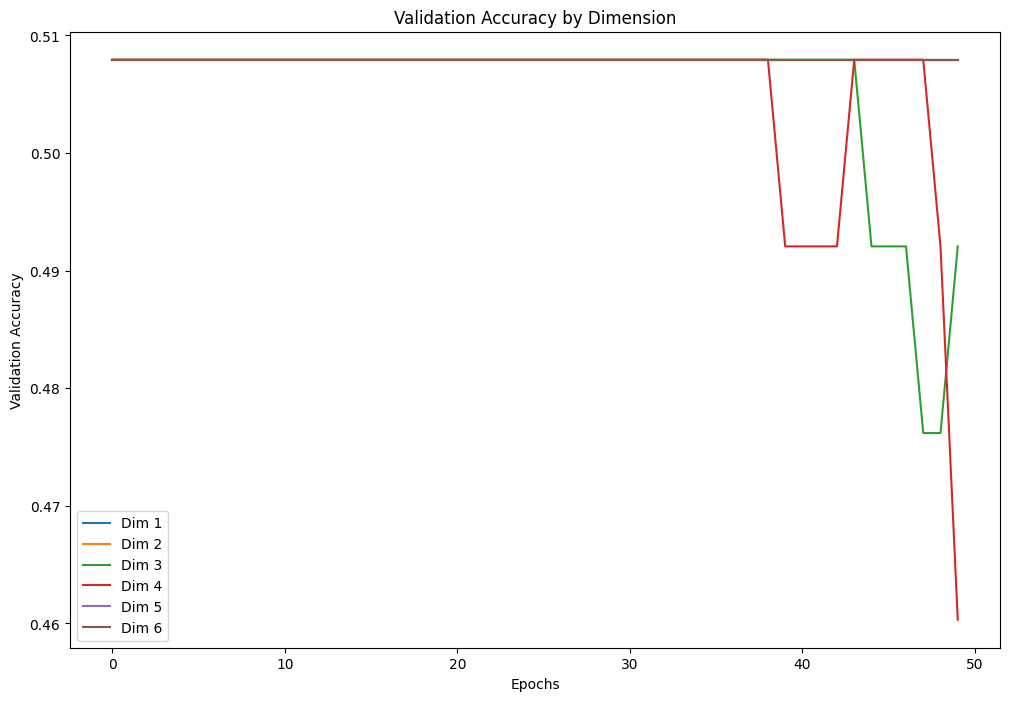

In [ ]:
# New idea: we are going to train a model for each dimension

samples, time_steps, dims = X_train.shape
models = []
histories = []
for d in range(dims):
    X_dim = X_train[:, :, d][:, :, np.newaxis]  # Use np.newaxis to add a new axis for the Keras model input shape
    model = tf.keras.models.Sequential([
        tf.keras.layers.GRU(64, kernel_initializer=tf.keras.initializers.Identity(gain=1.0)),
        tf.keras.layers.Dense(5, activation="softmax")
    ])
    model.build(input_shape=(None, time_steps, 1))
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer="adam",
        metrics=['accuracy']
    )
    print(X_dim.shape)      # Should be (n_samples, n_timesteps, 1)
    print(y_train.shape)    # Should be (n_samples,)
    hist = model.fit(X_dim, y_train, validation_split=.3, epochs=50)
    histories.append(hist)
    models.append(model)

# Evolution of accuracy for each dimension
plt.figure(figsize=(12, 8))
for d, hist in enumerate(histories):
    plt.plot(hist.history["val_accuracy"], label=f"Dim {d+1}")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Dimension")
plt.legend()
plt.show()

In [ ]:
# We proceed to a majority voting for the prediction of the test set
from scipy.stats import mode

predictions = []
for d in range(dims):
    X_dim = X_test[:, :, d][:, :, np.newaxis]
    pred = models[d].predict(X_dim)
    pred_classes = np.argmax(pred, axis=1)  # (n_samples,)
    predictions.append(pred_classes)

# predictions: (n_dims, n_samples)
predictions = np.array(predictions)

# Majority voting across dimensions (axis=0)
final_predictions = mode(predictions, axis=0).mode.flatten()  # (n_samples,)

# Évaluation
from sklearn.metrics import accuracy_score, classification_report

target_names = [name.decode('utf-8') if isinstance(name, bytes) else name for name in le.classes_]

accuracy = accuracy_score(y_test, final_predictions)
print(f"Final accuracy after majority voting: {accuracy:.4f}")
print(classification_report(y_test, final_predictions, target_names=target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 958ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 591ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 554ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step
Final accuracy after majority voting: 0.4231
              precision    recall  f1-score   support

           1       0.42      1.00      0.59        22
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00         3

    accuracy                           0.42        52
   macro avg       0.08      0.20      0.12        52
weighted avg       0.18      0.42      0.25        52



In [ ]:
# Let’s now implement a few new approaches

Idea 1 : Decomposition

In [ ]:
# First we decompose the time series into segments of 200 time steps

In [11]:
segment_length = 200  # time steps per segment
n_dims = X.shape[2]  # dimensions

# Initialize new datasets
X_segments = []
y_segments = []

for i in range(X.shape[0]):

    full_series = X[i]
    label = y[i]

    # Split the full time series into segments of segment_length
    n_segments = full_series.shape[0] // segment_length
    for j in range(n_segments):
        segment = full_series[j * segment_length:(j + 1) * segment_length, :]
        X_segments.append(segment)
        y_segments.append(label)

X_segments = np.array(X_segments)
y_segments = np.array(y_segments)

print(f"Segmented X shape: {X_segments.shape}")
print(f"Segmented y shape: {y_segments.shape}")

# Split into train and test sets
X_train_segments, X_test_segments, y_train_segments, y_test_segments = train_test_split(X_segments, y_segments, test_size=0.2, random_state=42)

print(f"X_train_segments shape: {X_train_segments.shape}")
print(f"y_train_segments shape: {y_train_segments.shape}")
print(f"X_test_segments shape: {X_test_segments.shape}")
print(f"y_test_segments shape: {y_test_segments.shape}")

Segmented X shape: (23051, 200, 6)
Segmented y shape: (23051,)
X_train_segments shape: (18440, 200, 6)
y_train_segments shape: (18440,)
X_test_segments shape: (4611, 200, 6)
y_test_segments shape: (4611,)


In [12]:
# Class weights for the segmented dataset

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_segments),
    y=y_train_segments
)
class_weight_dict = dict(zip(np.unique(y_train_segments), class_weights))

In [13]:
# Now we can train a LSTM model on these segments

lstm_segments = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units=64, return_sequences=False),
    #tf.keras.layers.LSTM(units=32, return_sequences=False),
    tf.keras.layers.Dense(units=5, activation="softmax")
])
lstm_segments.build(input_shape=(None, segment_length, n_dims))
lstm_segments.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_segments.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,501 (72.27 KB)

 Trainable params: 18,501 (72.27 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
hist = lstm_segments.fit(X_train_segments, y_train_segments, validation_split=0.3, epochs=50, class_weight=class_weight_dict)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.2288 - loss: 1.5674 - val_accuracy: 0.1931 - val_loss: 1.7027
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.2542 - loss: 1.5258 - val_accuracy: 0.3874 - val_loss: 1.4274
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.3557 - loss: 1.3441 - val_accuracy: 0.4112 - val_loss: 1.3065
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.4111 - loss: 1.2317 - val_accuracy: 0.4042 - val_loss: 1.3918
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.4077 - loss: 1.2303 - val_accuracy: 0.4671 - val_loss: 1.1417
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.4603 - loss: 1.1871 - val_accuracy: 0.4279 - val_loss: 1.2263
Epoch 7/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.4204 - loss: 1.3814 - val_accuracy: 0.3693 - val_loss: 1.3679
Epoch 8/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.3982 - loss: 1.2973 - 

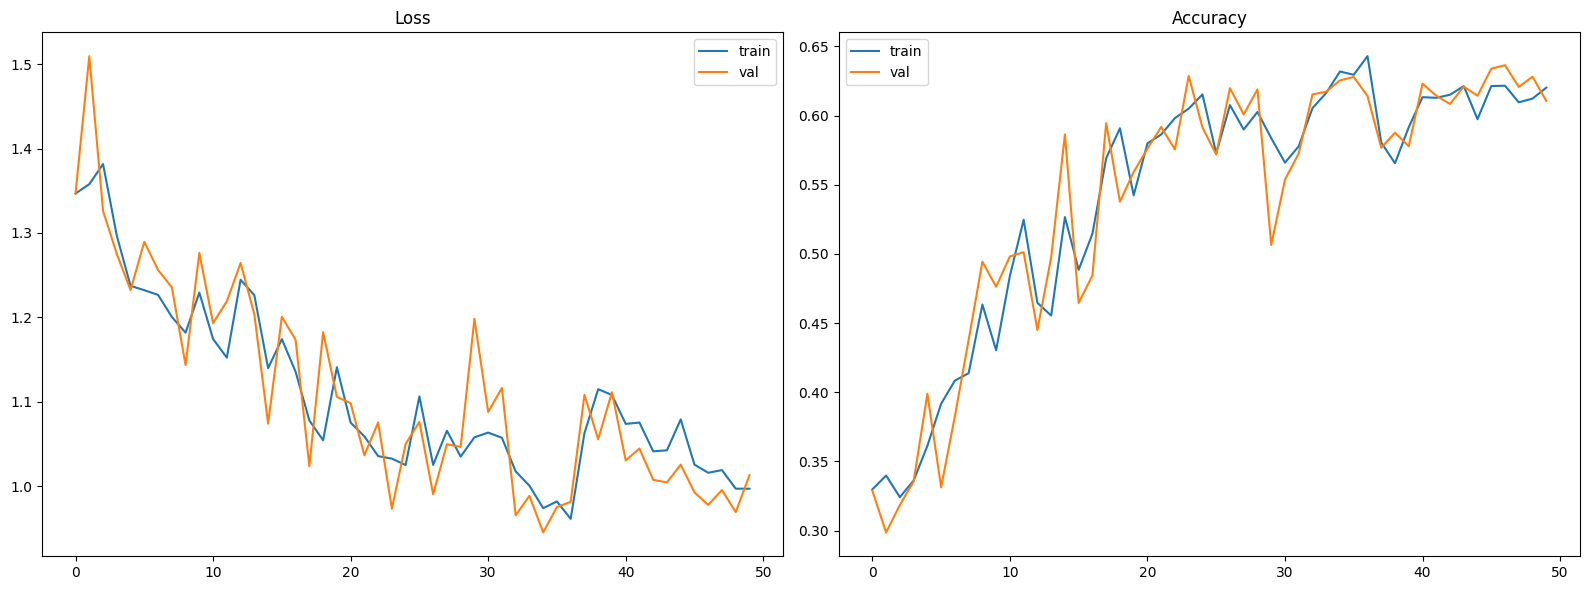

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lstm_segments.evaluate(X_test_segments, y_test_segments)

145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5987 - loss: 1.0159


[1.0075756311416626, 0.6087616682052612]

Idea 2 : Downsampling

In [ ]:
# Downsampling the time series to approximately 500 time steps

In [ ]:
downsample_length = 500  # Target number of time steps
n_dims = X.shape[2]  # dimensions

# Initialize new datasets
X_downsampled = []
y_downsampled = []

for i in range(X.shape[0]):

    full_series = X[i]
    label = y[i]

    # Downsample
    downsampled_series = full_series[::full_series.shape[0] // downsample_length, :]
    X_downsampled.append(downsampled_series)
    y_downsampled.append(label)

X_downsampled = np.array(X_downsampled)
y_downsampled = np.array(y_downsampled)

print(f"Downsampled X shape: {X_downsampled.shape}")
print(f"Downsampled y shape: {y_downsampled.shape}")

Downsampled X shape: (259, 514, 6)
Downsampled y shape: (259,)


In [ ]:
X_train_downsampled, X_test_downsampled, y_train_downsampled, y_test_downsampled = train_test_split(X_downsampled, y_downsampled, test_size=0.2, random_state=42)

print(f"X_train_downsampled shape: {X_train_downsampled.shape}")
print(f"y_train_downsampled shape: {y_train_downsampled.shape}")
print(f"X_test_downsampled shape: {X_test_downsampled.shape}")
print(f"y_test_downsampled shape: {y_test_downsampled.shape}")

X_train_downsampled shape: (207, 514, 6)
y_train_downsampled shape: (207,)
X_test_downsampled shape: (52, 514, 6)
y_test_downsampled shape: (52,)


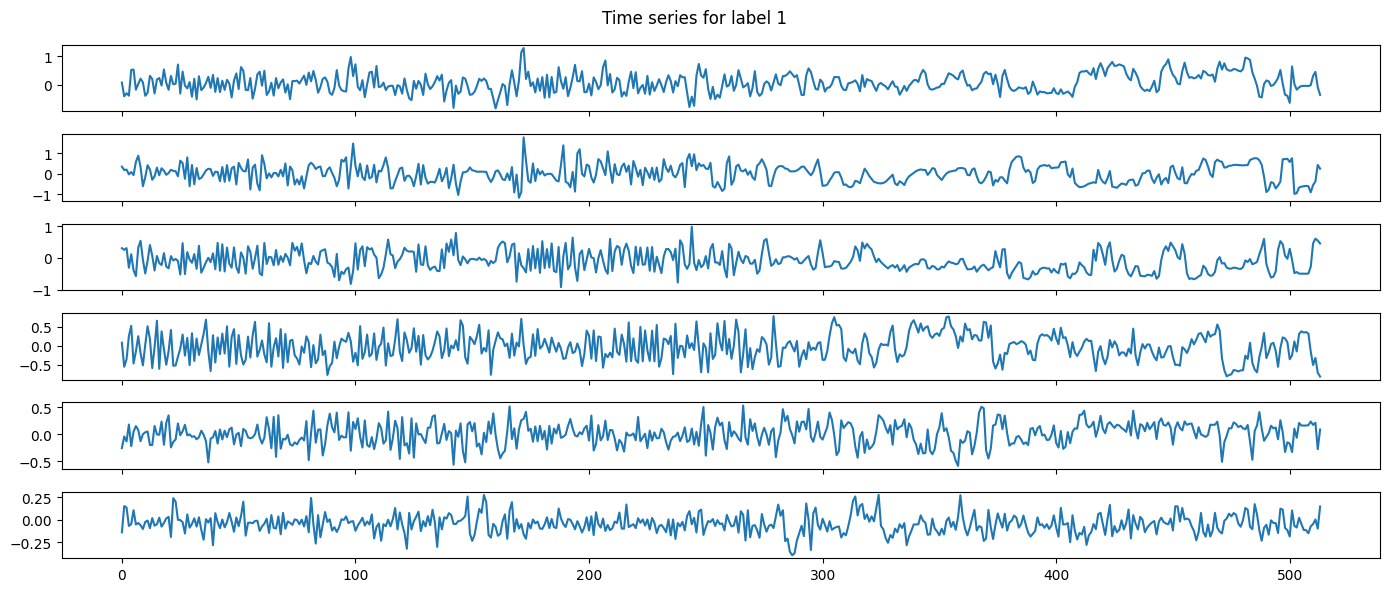

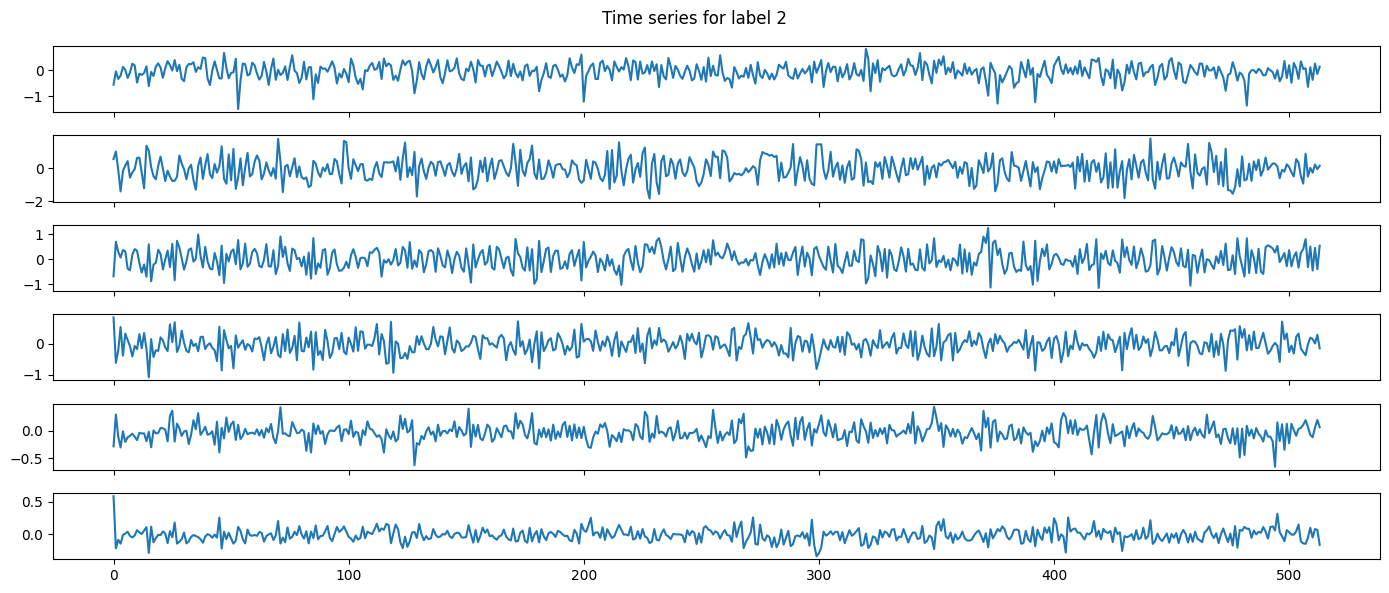

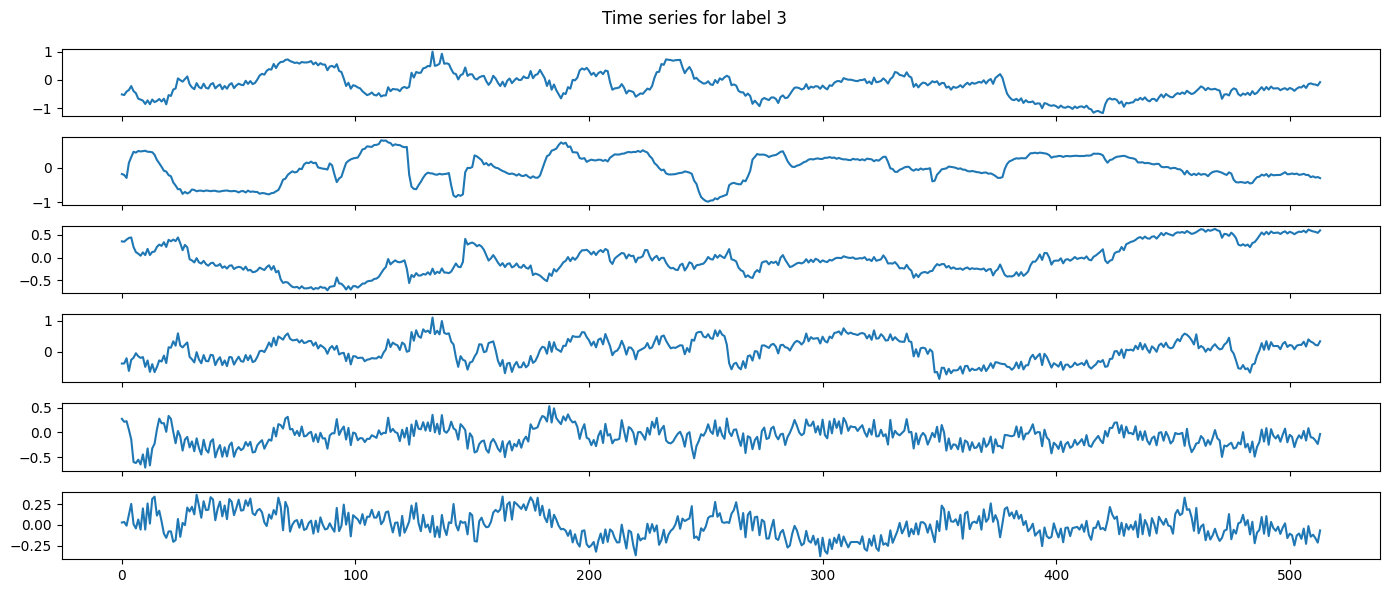

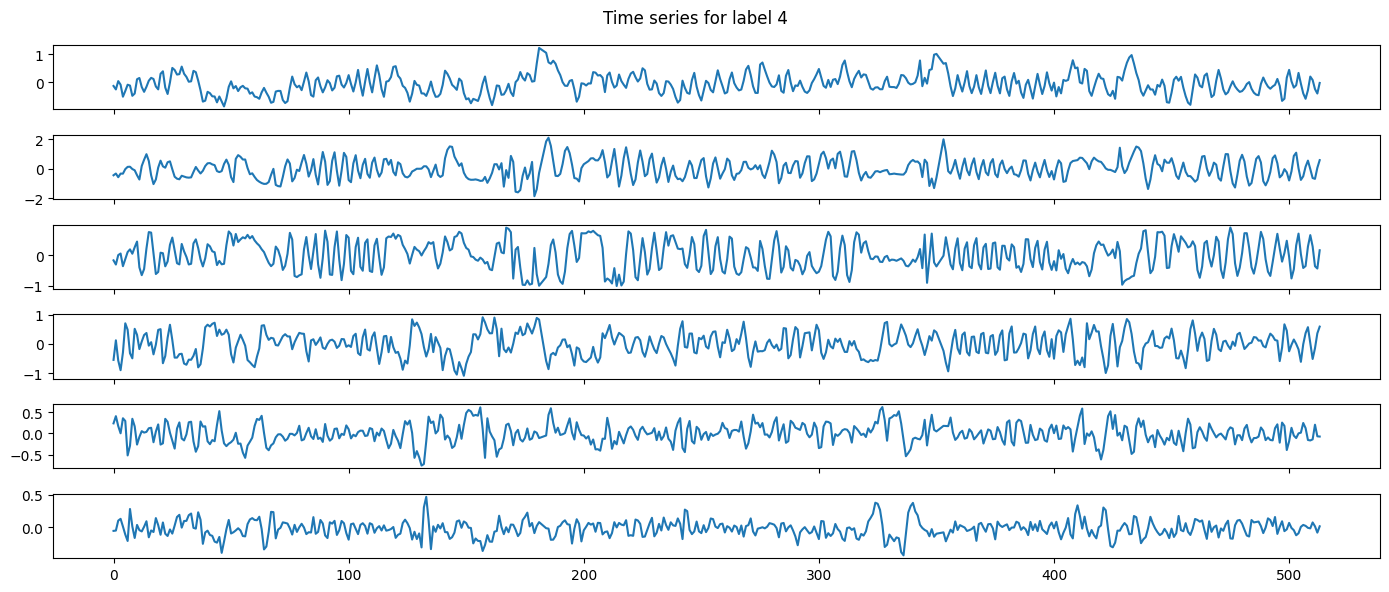

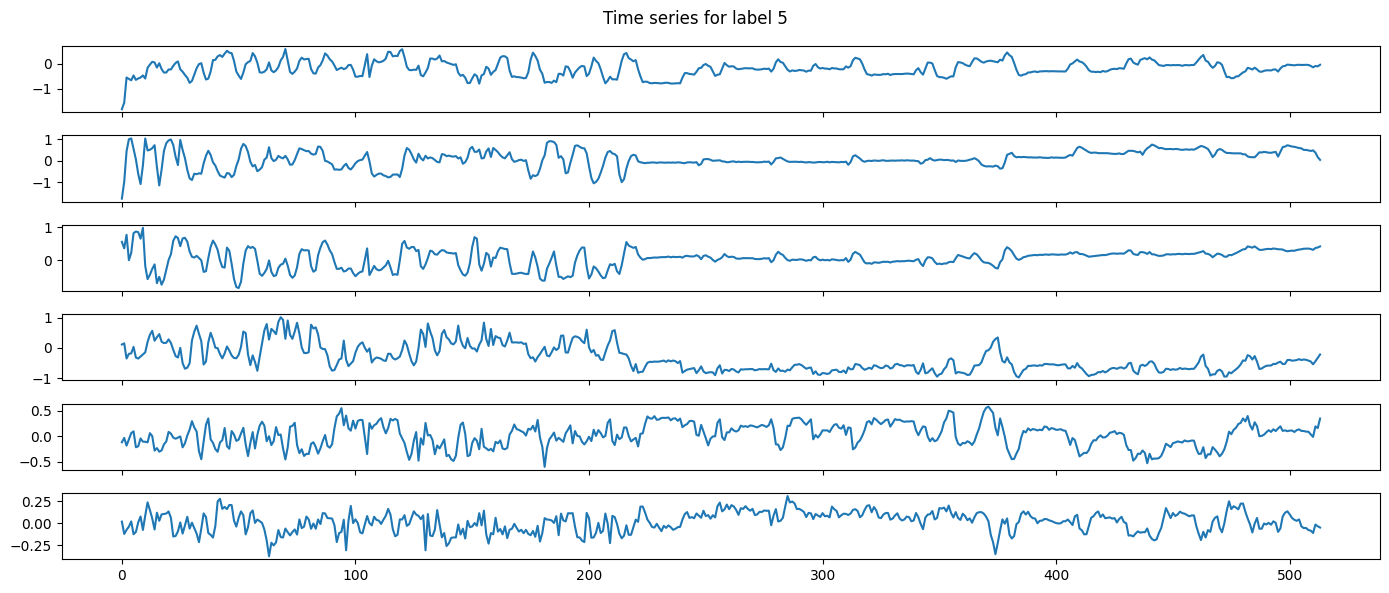

In [ ]:
# unique labels
unique_labels = np.unique(y_downsampled)

for label in unique_labels:

    rows_with_label = X_downsampled[y_downsampled == label]
    row = rows_with_label[0]

    # Build time series for each dimension
    n_dims = row.shape[1]
    series_by_dim = []
    for d in range(n_dims):
        series = row[:, d]
        series_by_dim.append(series)

    # Plot
    fig, axs = plt.subplots(n_dims, 1, figsize=(14, 6), sharex=True)
    for d in range(n_dims):
        axs[d].plot(series_by_dim[d])
    plt.suptitle(f'Time series for label {label+1}')
    plt.tight_layout()
    plt.show()

In [ ]:
# Class weights for the downsampled dataset

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_downsampled),
    y=y_train_downsampled
)
class_weight_dict = dict(zip(np.unique(y_train_downsampled), class_weights))

In [ ]:
lstm_downsampled = tf.keras.models.Sequential([
    tf.keras.layers.GRU(units=64, return_sequences=False),
    #tf.keras.layers.LSTM(units=32, return_sequences=True),
    #tf.keras.layers.LSTM(units=16),
    tf.keras.layers.Dense(units=len(np.unique(y_train_downsampled)), activation="softmax")
])
lstm_downsampled.build(input_shape=(None, downsample_length, n_dims))
lstm_downsampled.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_downsampled.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,149 (55.27 KB)

 Trainable params: 14,149 (55.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = lstm_downsampled.fit(X_train_downsampled, y_train_downsampled, validation_split=0.3, epochs=100, batch_size=16, class_weight=class_weight_dict)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6532 - loss: 0.6620 - val_accuracy: 0.3333 - val_loss: 1.6098
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6550 - loss: 0.5949 - val_accuracy: 0.3492 - val_loss: 1.5634
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5682 - loss: 0.9549 - val_accuracy: 0.3492 - val_loss: 1.5634
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6403 - loss: 0.7803 - val_accuracy: 0.3968 - val_loss: 1.4671
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6085 - loss: 0.7299 - val_accuracy: 0.3492 - val_loss: 1.5701
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.6617 - val_accuracy: 0.3175 - val_loss: 1.5607
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6832 - loss: 0.6280 - val_accuracy: 0.3810 - val_loss: 1.4838
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7344 - loss: 0.5644 - val_accuracy: 0.3810 - val_loss:

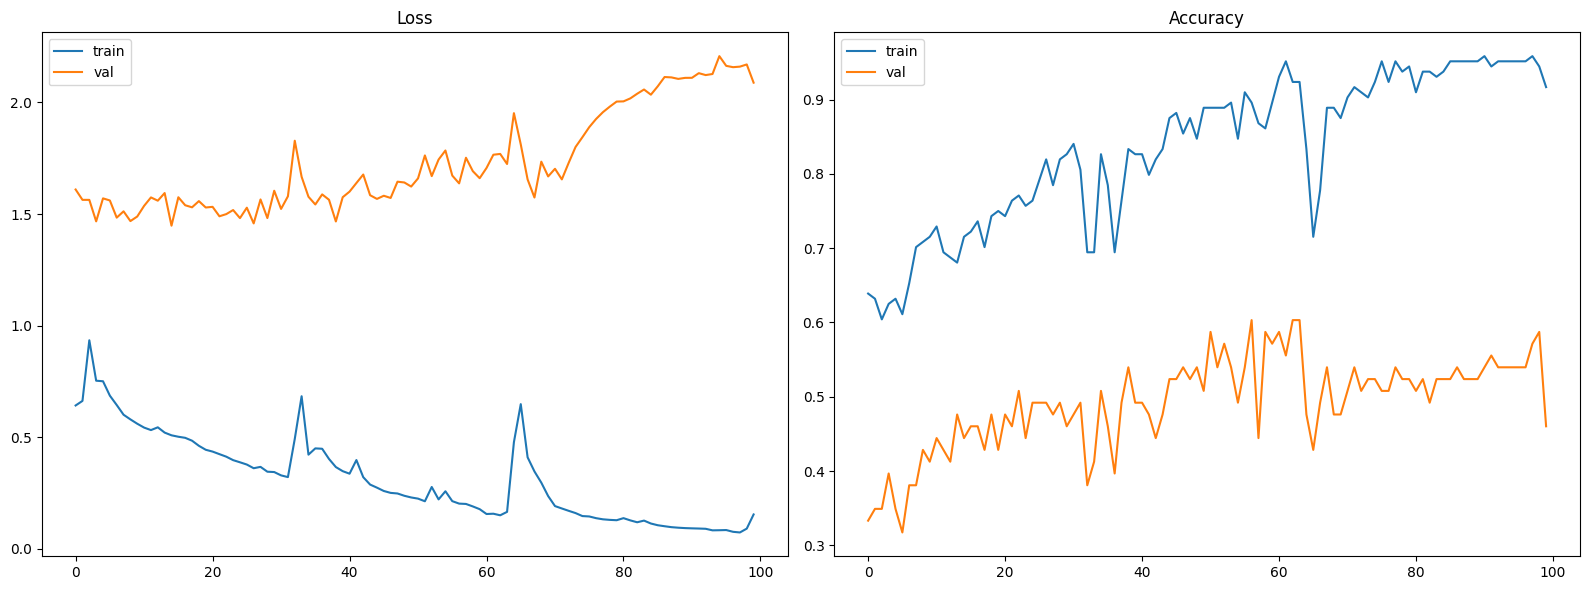

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lstm_downsampled.evaluate(X_test_downsampled, y_test_downsampled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3686 - loss: 2.6536


[2.710052251815796, 0.36538460850715637]

Idea 3 : CNN

In [ ]:
# Compute class weights to balance the dataset
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

In [ ]:
# Define the CNN model
CNN = tf.keras.Sequential([

    #tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    #tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(filters=64, kernel_size=15, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Flatten(),

    # Classification
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=5, activation='softmax')
])

CNN.build(input_shape=(None, 17984, n_dims))  # Input shape: (batch_size, time_steps, n_dims)

# Compile the model
CNN.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 17980, 32)      │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 8990, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 8976, 64)       │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 4488, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 287232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    18,382,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,415,013 (70.25 MB)

 Trainable params: 18,415,013 (70.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = CNN.fit(X_train, y_train, validation_split=0.3, epochs=50, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 515ms/step - accuracy: 0.1874 - loss: 8.5431 - val_accuracy: 0.1746 - val_loss: 3.2572
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.2921 - loss: 1.9491 - val_accuracy: 0.1746 - val_loss: 1.5413
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.3980 - loss: 1.4783 - val_accuracy: 0.5397 - val_loss: 1.2888
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.6228 - loss: 1.2927 - val_accuracy: 0.3810 - val_loss: 1.2772
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.6568 - loss: 0.9693 - val_accuracy: 0.6190 - val_loss: 1.0448
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9103 - loss: 0.8116 - val_accuracy: 0.5556 - val_loss: 1.0994
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9782 - loss: 0.2055 - val_accuracy: 0.6190 - val_loss: 1.2719
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9920 - loss: 0.0996 - val_accuracy: 0.6349 - val_loss: 1.

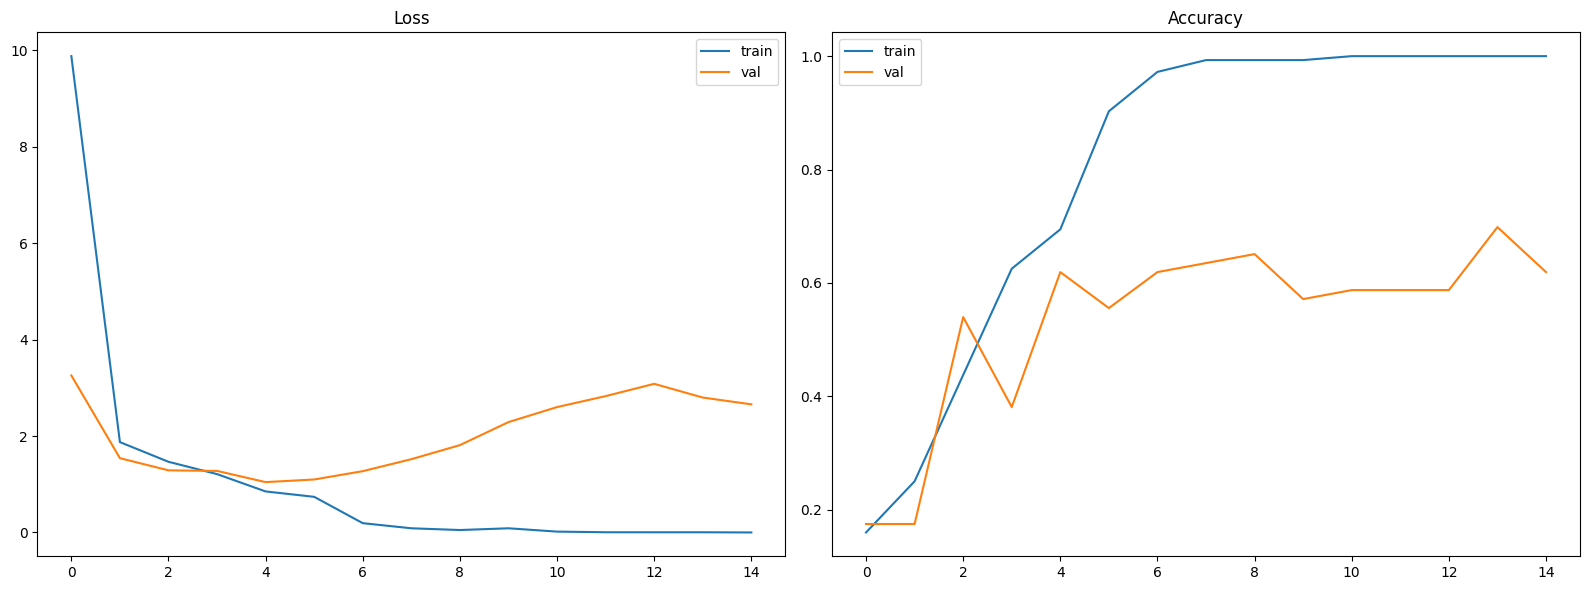

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist.history["loss"], label="train")
axs[0].plot(hist.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist.history["accuracy"], label="train")
axs[1].plot(hist.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
CNN.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.5489 - loss: 1.1800


[1.1469409465789795, 0.557692289352417]

In [ ]:
# CNN architecture with Lasso regularization

CNN_lasso = tf.keras.Sequential([
    #tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=tf.keras.regularizers.L1(0.0001)),
    #tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', kernel_regularizer=tf.keras.regularizers.L1(0.0001)),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(filters=64, kernel_size=15, activation='relu', kernel_regularizer=tf.keras.regularizers.L1(0.0001)),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Flatten(),

    # Classification
    tf.keras.layers.Dense(units=64, activation='relu', kernel_regularizer=tf.keras.regularizers.L1(0.0001)),
    tf.keras.layers.Dense(units=5, activation='softmax', kernel_regularizer=tf.keras.regularizers.L1(0.0001))
])

CNN_lasso.build(input_shape=(None, 17984, n_dims))  # Input shape: (batch_size, time_steps, n_dims)

# Compile the model
CNN_lasso.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_lasso.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 17980, 32)      │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 8990, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 8976, 64)       │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 4488, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 287232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │    18,382,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,415,013 (70.25 MB)

 Trainable params: 18,415,013 (70.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist_lasso = CNN_lasso.fit(X_train, y_train, validation_split=0.3, epochs=50, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 707ms/step - accuracy: 0.1905 - loss: 12.1882 - val_accuracy: 0.1905 - val_loss: 7.8569
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.4170 - loss: 8.5192 - val_accuracy: 0.2540 - val_loss: 6.7073
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4476 - loss: 5.9975 - val_accuracy: 0.3016 - val_loss: 6.3102
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.4631 - loss: 5.7553 - val_accuracy: 0.4444 - val_loss: 5.7681
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.8413 - loss: 4.8728 - val_accuracy: 0.4127 - val_loss: 5.4011
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.9342 - loss: 4.1034 - val_accuracy: 0.6508 - val_loss: 5.0690
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.9654 - loss: 3.6515 - val_accuracy: 0.5873 - val_loss: 5.0199
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.9787 - loss: 3.3131 - val_accuracy: 0.3492 - val_loss

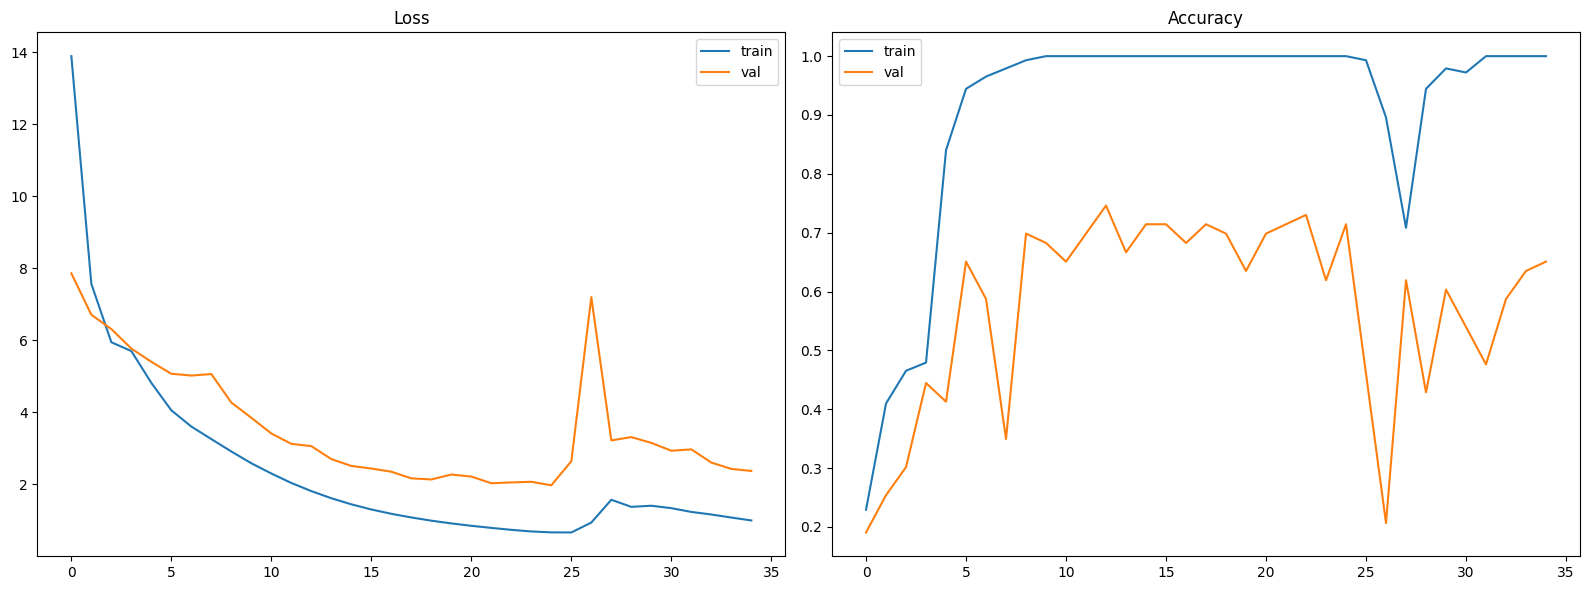

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist_lasso.history["loss"], label="train")
axs[0].plot(hist_lasso.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist_lasso.history["accuracy"], label="train")
axs[1].plot(hist_lasso.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
CNN_lasso.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.5593 - loss: 2.5119


[2.4095380306243896, 0.557692289352417]

In [ ]:
# CNN architecture with Ridge regularization

CNN_ridge = tf.keras.Sequential([
    #tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    #tf.keras.layers.MaxPooling1D(pool_size=2),  # Reduce time steps by half

    tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(filters=64, kernel_size=15, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Flatten(),

    # Classification
    tf.keras.layers.Dense(units=64, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dense(units=5, activation='softmax', kernel_regularizer=tf.keras.regularizers.L2(0.001))
])

CNN_ridge.build(input_shape=(None, 17984, n_dims))  # Input shape: (batch_size, time_steps, n_dims)

# Compile the model
CNN_ridge.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_ridge.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 17980, 32)      │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 8990, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 8976, 64)       │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 4488, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 287232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │    18,382,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,415,013 (70.25 MB)

 Trainable params: 18,415,013 (70.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist_ridge = CNN_ridge.fit(X_train, y_train, validation_split=0.3, epochs=50, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 701ms/step - accuracy: 0.3070 - loss: 7.3553 - val_accuracy: 0.1111 - val_loss: 3.6268
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.2276 - loss: 2.7038 - val_accuracy: 0.1270 - val_loss: 2.0121
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.6953 - loss: 1.6614 - val_accuracy: 0.6032 - val_loss: 1.7914
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8517 - loss: 1.2254 - val_accuracy: 0.6825 - val_loss: 1.7606
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9361 - loss: 0.7530 - val_accuracy: 0.5714 - val_loss: 2.0591
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.9868 - loss: 0.5504 - val_accuracy: 0.6825 - val_loss: 2.6026
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9977 - loss: 0.5190 - val_accuracy: 0.6032 - val_loss: 3.4280
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9572 - loss: 0.5509 - val_accuracy: 0.6349 - val_loss: 

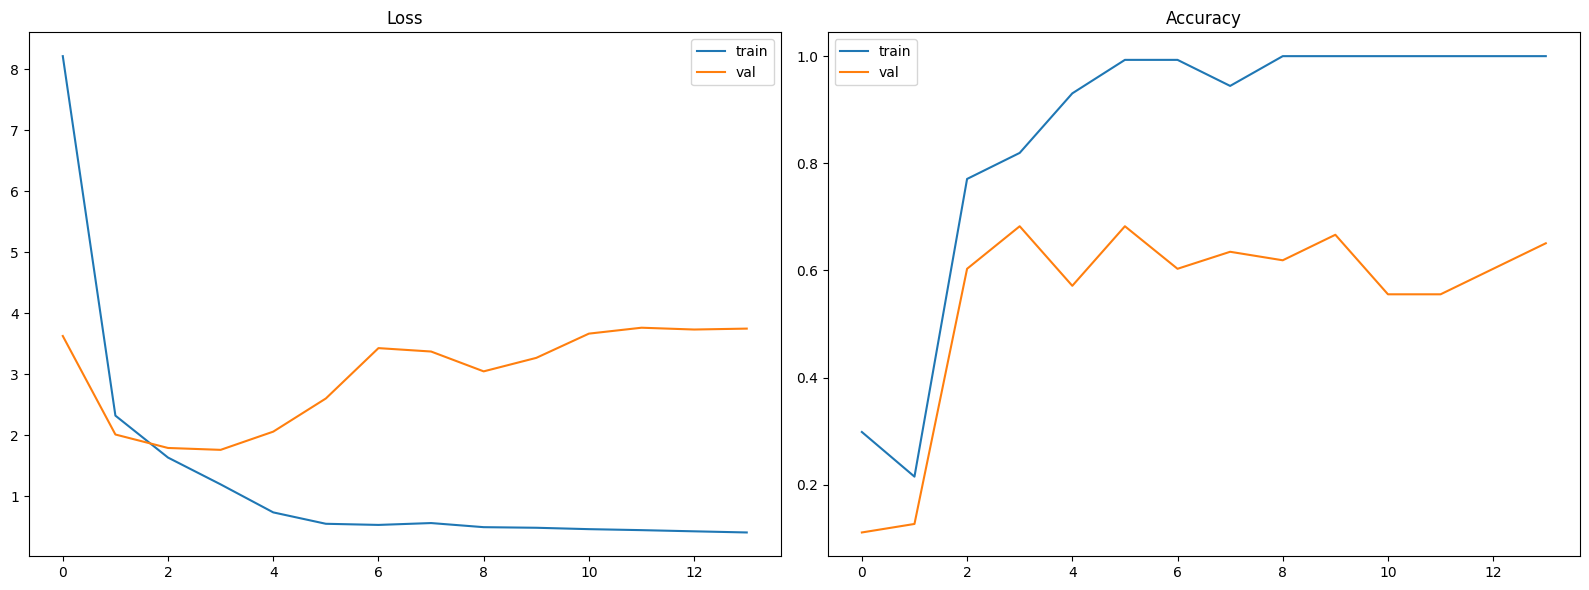

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist_ridge.history["loss"], label="train")
axs[0].plot(hist_ridge.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist_ridge.history["accuracy"], label="train")
axs[1].plot(hist_ridge.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
CNN_ridge.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.5128 - loss: 1.6658


[1.6464366912841797, 0.5192307829856873]

Idea 5 : CNN + GRU

In [ ]:
# Hybrid CNN + GRU architecture for time series classification

CNN_GRU = tf.keras.Sequential([
    #tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, activation='relu', input_shape=(17984, 6)),
    #tf.keras.layers.BatchNormalization(),
    #tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(32, kernel_size=5, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(64, kernel_size=15, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Dropout(0.3),

    # GRU for temporal dependencies
    tf.keras.layers.GRU(64, return_sequences=False),

    tf.keras.layers.Dropout(0.3),

    # Classification
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

CNN_GRU.build(input_shape=(None, 17984, 6))  # Input shape: (batch_size, time_steps, n_dims)

CNN_GRU.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_GRU.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 8990, 32)       │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8990, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 4495, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 2241, 64)       │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2241, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 1120, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1120, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,605 (240.64 KB)

 Trainable params: 61,413 (239.89 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
hist_CNN_GRU = CNN_GRU.fit(X_train, y_train, validation_split=0.3, epochs=50, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.1975 - loss: 1.7034 - val_accuracy: 0.2698 - val_loss: 1.6095
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2692 - loss: 1.5383 - val_accuracy: 0.2698 - val_loss: 1.6047
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.3922 - loss: 1.5250 - val_accuracy: 0.1429 - val_loss: 1.6014
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3644 - loss: 1.4225 - val_accuracy: 0.2063 - val_loss: 1.5963
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4084 - loss: 1.3716 - val_accuracy: 0.2540 - val_loss: 1.5915
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5075 - loss: 1.0924 - val_accuracy: 0.3333 - val_loss: 1.5820
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5153 - loss: 1.2313 - val_accuracy: 0.3810 - val_loss: 1.5700
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.5942 - loss: 1.1176 - val_accuracy: 0.4444 - val_loss: 1.556

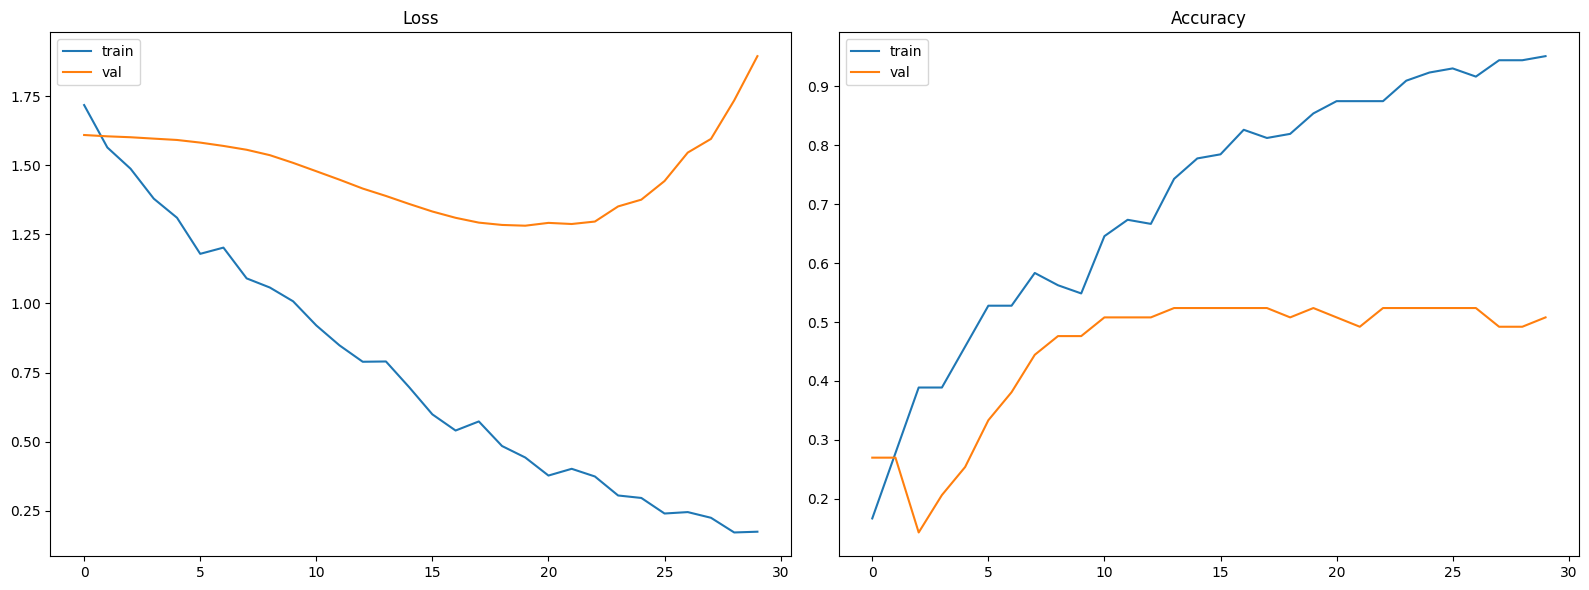

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist_CNN_GRU.history["loss"], label="train")
axs[0].plot(hist_CNN_GRU.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist_CNN_GRU.history["accuracy"], label="train")
axs[1].plot(hist_CNN_GRU.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
CNN_GRU.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4071 - loss: 1.5631


[1.5300781726837158, 0.42307692766189575]

In [ ]:
# We can try to add a ridge regularizer to the previous architecture

In [ ]:
# CNN + GRU architecture with Ridge regularization

CNN_GRU_ridge = tf.keras.Sequential([

    tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(128, kernel_size=5, strides=2, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(256, kernel_size=3, strides=2, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Dropout(0.3),

    # GRU for temporal dependencies with Ridge regularization
    tf.keras.layers.GRU(64, return_sequences=False,
                       kernel_regularizer=tf.keras.regularizers.L2(0.001),
                       recurrent_regularizer=tf.keras.regularizers.L2(0.001)),

    tf.keras.layers.Dropout(0.3),

    # Classification
    tf.keras.layers.Dense(64, activation='relu',
                         kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dense(5, activation='softmax',
                         kernel_regularizer=tf.keras.regularizers.L2(0.001))
])

CNN_GRU_ridge.build(input_shape=(None, 17984, 6))  # Input shape: (batch_size, time_steps, n_dims)

CNN_GRU_ridge.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_GRU_ridge.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 8989, 64)       │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8989, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 4494, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 2245, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2245, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 1122, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 560, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 560, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 280, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 280, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,501 (822.27 KB)

 Trainable params: 209,605 (818.77 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
hist_CNN_GRU_ridge = CNN_GRU_ridge.fit(X_train, y_train, validation_split=0.3, epochs=50, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 289ms/step - accuracy: 0.2824 - loss: 2.4744 - val_accuracy: 0.1111 - val_loss: 2.2534
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5579 - loss: 1.9519 - val_accuracy: 0.0952 - val_loss: 2.2630
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6306 - loss: 1.6689 - val_accuracy: 0.0635 - val_loss: 2.2554
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5830 - loss: 1.7080 - val_accuracy: 0.1270 - val_loss: 2.2336
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6644 - loss: 1.4875 - val_accuracy: 0.1270 - val_loss: 2.2031
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7360 - loss: 1.4070 - val_accuracy: 0.1429 - val_loss: 2.1696
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7674 - loss: 1.3351 - val_accuracy: 0.1746 - val_loss: 2.1325
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.7711 - loss: 1.2718 - val_accuracy: 0.2063 - val_loss: 2.098

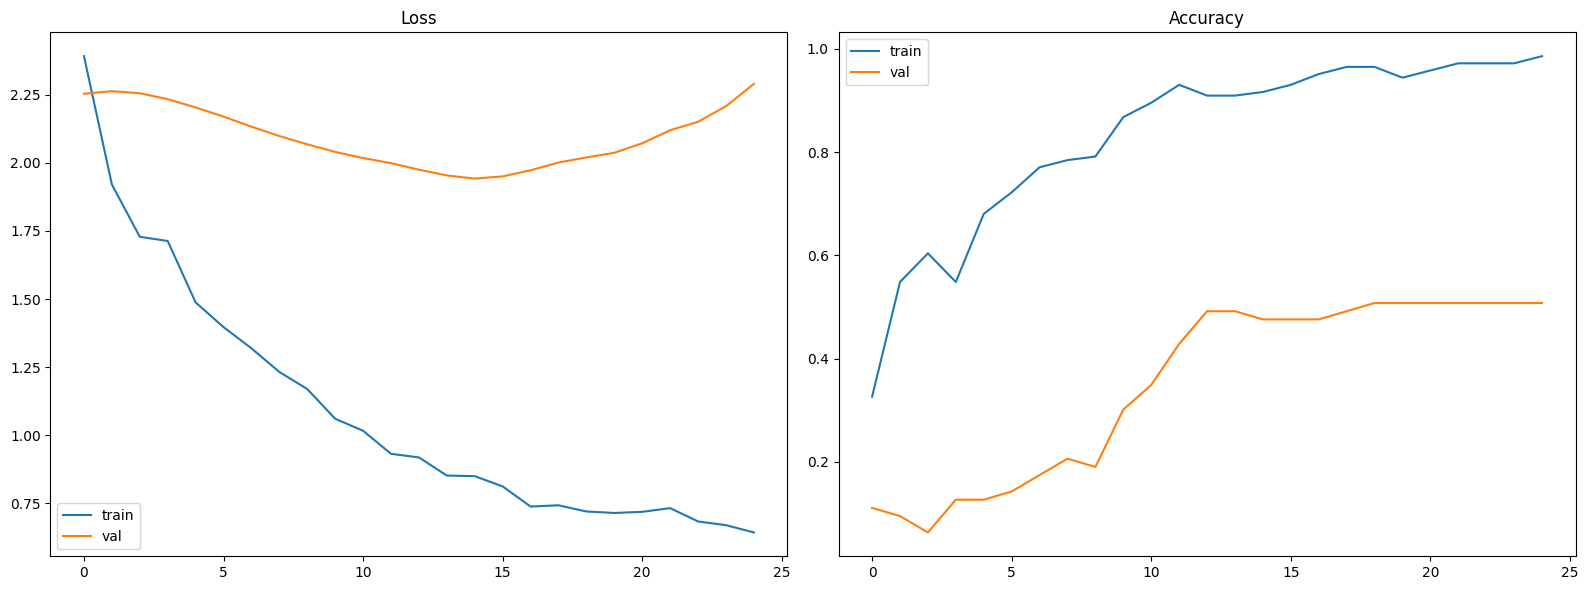

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist_CNN_GRU_ridge.history["loss"], label="train")
axs[0].plot(hist_CNN_GRU_ridge.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist_CNN_GRU_ridge.history["accuracy"], label="train")
axs[1].plot(hist_CNN_GRU_ridge.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
CNN_GRU_ridge.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4407 - loss: 2.0823


[2.080197811126709, 0.4423076808452606]

In [ ]:
# CNN + LSTM architecture with Ridge regularization

CNN_LSTM_ridge = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(128, kernel_size=5, strides=2, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(256, kernel_size=3, strides=2, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Dropout(0.3),

    # LSTM for temporal dependencies with Ridge regularization
    tf.keras.layers.LSTM(64, return_sequences=False,
                        kernel_regularizer=tf.keras.regularizers.L2(0.001),
                        recurrent_regularizer=tf.keras.regularizers.L2(0.001)),

    tf.keras.layers.Dropout(0.3),

    # Classification
    tf.keras.layers.Dense(64, activation='relu',
                         kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dense(5, activation='softmax',
                         kernel_regularizer=tf.keras.regularizers.L2(0.001))
])

CNN_LSTM_ridge.build(input_shape=(None, 17984, 6))  # Input shape: (batch_size, time_steps, n_dims)

CNN_LSTM_ridge.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_LSTM_ridge.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_28 (Conv1D)              │ (None, 8989, 64)       │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8989, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 4494, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 2245, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 2245, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 1122, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 560, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 560, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 280, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 280, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,853 (901.77 KB)

 Trainable params: 229,957 (898.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
hist_CNN_LSTM_ridge = CNN_LSTM_ridge.fit(X_train, y_train, validation_split=0.3, epochs=50, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step - accuracy: 0.2299 - loss: 2.2988 - val_accuracy: 0.0952 - val_loss: 2.2710
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4372 - loss: 2.0474 - val_accuracy: 0.0952 - val_loss: 2.2850
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.5454 - loss: 1.8930 - val_accuracy: 0.0794 - val_loss: 2.2869
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6253 - loss: 1.7890 - val_accuracy: 0.0635 - val_loss: 2.2767
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6503 - loss: 1.6072 - val_accuracy: 0.1429 - val_loss: 2.2509
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7545 - loss: 1.4764 - val_accuracy: 0.3175 - val_loss: 2.2149
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7658 - loss: 1.5380 - val_accuracy: 0.4127 - val_loss: 2.1789
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8207 - loss: 1.3253 - val_accuracy: 0.5079 - val_loss: 2.

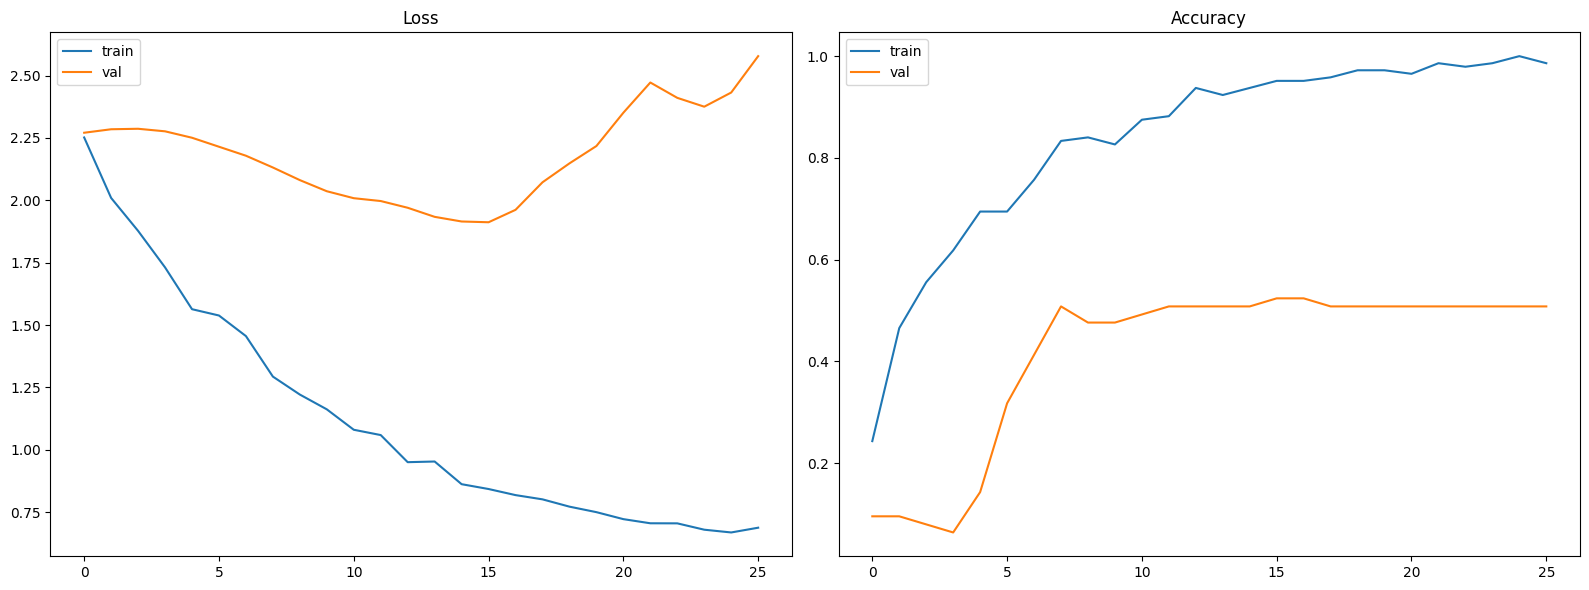

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(hist_CNN_LSTM_ridge.history["loss"], label="train")
axs[0].plot(hist_CNN_LSTM_ridge.history["val_loss"], label="val")
axs[0].set_title("Loss")
axs[0].legend()

axs[1].plot(hist_CNN_LSTM_ridge.history["accuracy"], label="train")
axs[1].plot(hist_CNN_LSTM_ridge.history["val_accuracy"], label="val")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
CNN_LSTM_ridge.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3838 - loss: 2.1990


[2.1710047721862793, 0.4038461446762085]

In [ ]:
# Now, we try to understand which characteristics of the motion (values along the six “eigenworms”) are more relevant for the outcome of the CNN classification method.

In [ ]:
# First, we analyze the gradient sensibility of the CNN and segmented LSTM model to each dimension in the space of the eigenWorms.

In [15]:
def gradient_sensitivity(model, X_test):

    X_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)

    with tf.GradientTape() as tape:  # Save the gradients
        tape.watch(X_tensor)
        predictions = model(X_tensor)
        target_class = tf.argmax(predictions, axis=1)  # predicted classes
        target_logits = tf.gather(predictions, target_class, axis=1, batch_dims=1)  # logits for the predicted classes

    gradients = tape.gradient(target_logits, X_tensor)  # Compute the gradients of the target logits with respect to the input features
    gradient_norms = tf.reduce_mean(tf.abs(gradients), axis=1)  # For each dimension, compute the mean absolute gradient norm across all time steps

    return gradient_norms.numpy()

In [16]:
def analyze_gradient_sensitivity(model, X_test):

    sensitivities = gradient_sensitivity(model, X_test)

    mean_sensitivity = np.mean(sensitivities, axis=0)
    std_sensitivity = np.std(sensitivities, axis=0)

    return mean_sensitivity, std_sensitivity

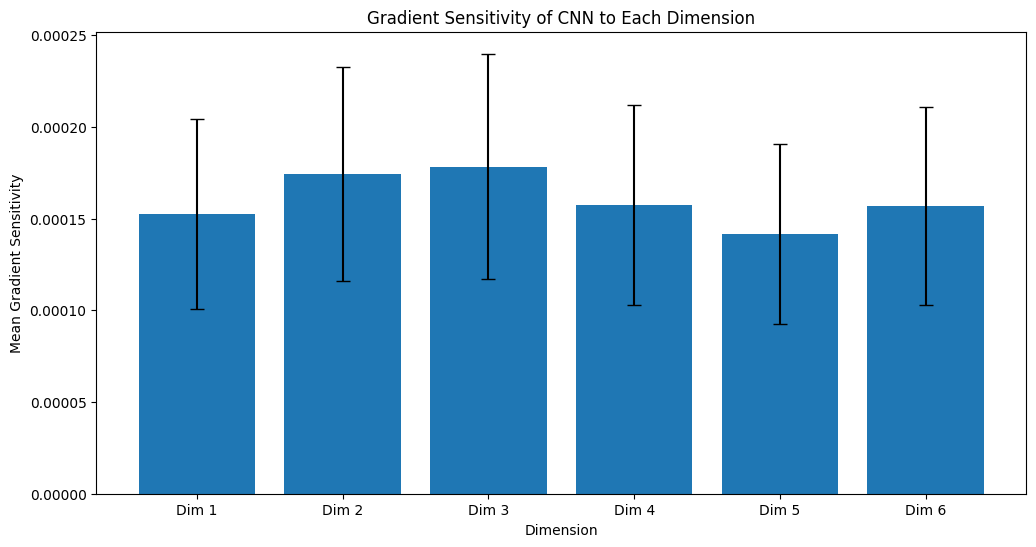

In [ ]:
# For the CNN model
mean_sensitivity, std_sensitivity = analyze_gradient_sensitivity(CNN, X_test)

# Plot the mean and standard deviation of the gradient sensitivity for each dimension
plt.figure(figsize=(12, 6))
plt.bar(range(len(mean_sensitivity)), mean_sensitivity, yerr=std_sensitivity, capsize=5)
plt.xlabel('Dimension')
plt.ylabel('Mean Gradient Sensitivity')
plt.title('Gradient Sensitivity of CNN to Each Dimension')
plt.xticks(range(len(mean_sensitivity)), [f'Dim {i+1}' for i in range(len(mean_sensitivity))])
plt.show()

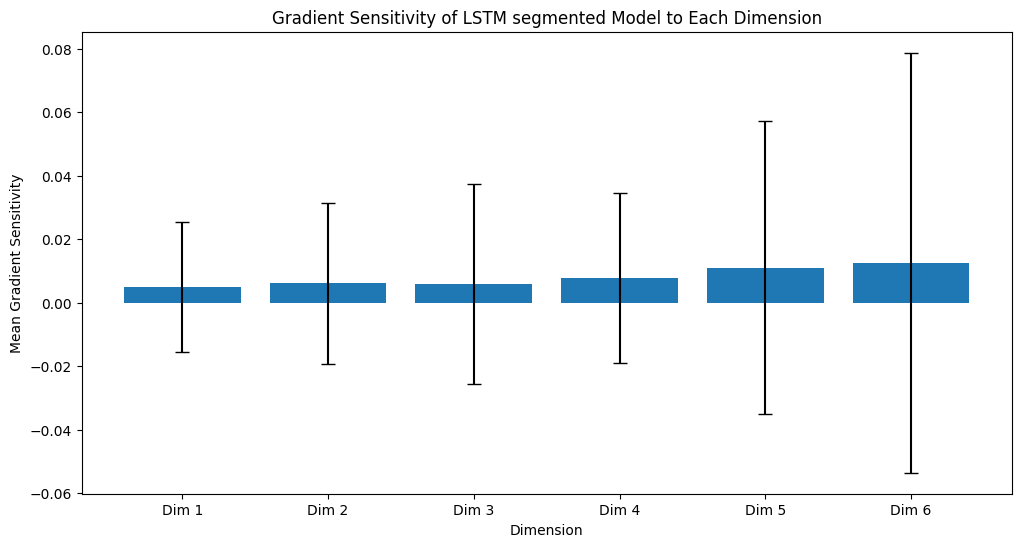

In [20]:
# Now, let us analyze the gradient sensitivity of the LSTM segmented model to each dimension in the space of the eigenWorms.
mean_sensitivity, std_sensitivity = analyze_gradient_sensitivity(lstm_segments, X_test_segments)

# Plot the mean and standard deviation of the gradient sensitivity for each dimension
plt.figure(figsize=(12, 6))
plt.bar(range(len(mean_sensitivity)), mean_sensitivity, yerr=std_sensitivity, capsize=5)
plt.xlabel('Dimension')
plt.ylabel('Mean Gradient Sensitivity')
plt.title('Gradient Sensitivity of LSTM segmented Model to Each Dimension')
plt.xticks(range(len(mean_sensitivity)), [f'Dim {i+1}' for i in range(len(mean_sensitivity))])
plt.show()
# rk : this graph is not interpretable

In [ ]:
# Secondly, we use a permutation method to analyze the importance of each dimension in the space of the eigenWorms.

In [18]:
from sklearn.metrics import accuracy_score

def permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42):
    # Performance without permutation
    baseline_predictions = model.predict(X_test, verbose=0)
    baseline_score = accuracy_score(y_test, np.argmax(baseline_predictions, axis=1))

    # Initialization
    n_dims = X_test.shape[2]
    importance_scores = np.zeros((n_dims, n_repeats))

    for dim in range(n_dims):
        # Average performance with permutation
        for repeat in range(n_repeats):
            X_permuted = np.copy(X_test)

            # Randomize different time steps for the current dimension
            np.random.seed(random_state + repeat)
            permuted_indices = np.random.permutation(len(X_test))
            X_permuted[:, :, dim] = X_test[permuted_indices, :, dim]

            permuted_predictions = model.predict(X_permuted, verbose=0)
            permuted_score = accuracy_score(y_test, np.argmax(permuted_predictions, axis=1))

            # Loss of performance due to permutation
            importance_scores[dim, repeat] = baseline_score - permuted_score

    # Mean and standard deviation
    importance_mean = np.mean(importance_scores, axis=1)
    importance_std = np.std(importance_scores, axis=1)

    return importance_mean, importance_std, baseline_score, importance_scores

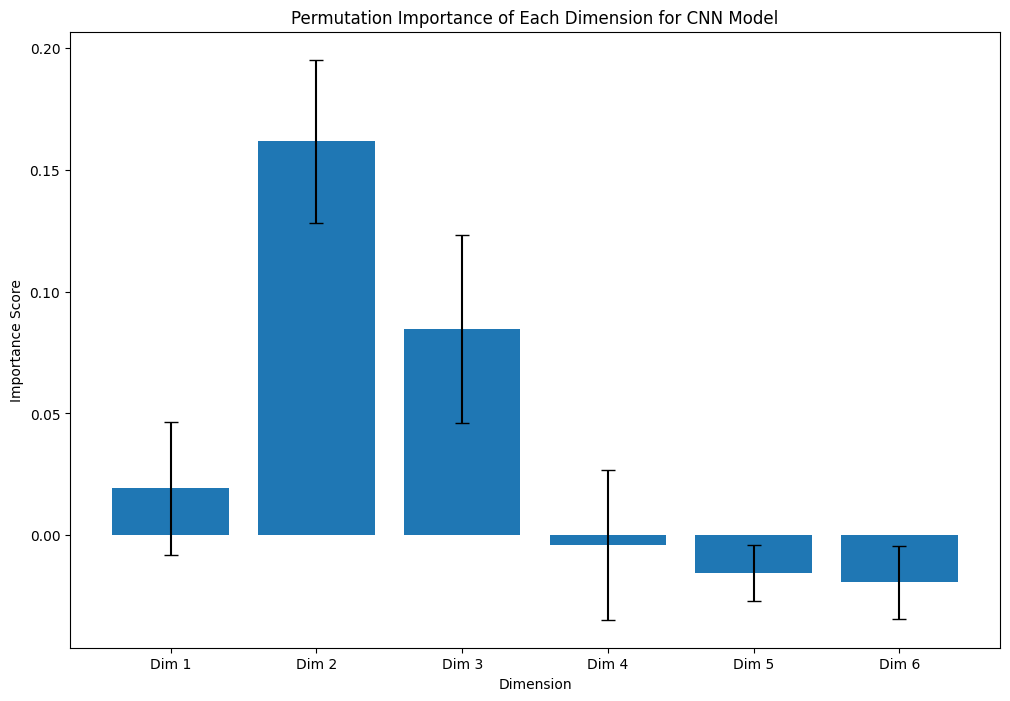

In [ ]:
# Plot the permutation importance for the CNN model
importance_mean, importance_std, baseline_score, importance_scores = permutation_importance(CNN, X_test, y_test)

plt.figure(figsize=(12,8))
plt.bar(range(len(importance_mean)), importance_mean, yerr=importance_std, capsize=5)
plt.xlabel('Dimension')
plt.ylabel('Importance Score')
plt.title('Permutation Importance of Each Dimension for CNN Model')
plt.xticks(range(6), [f'Dim {i+1}' for i in range(len(importance_mean))])
plt.show()

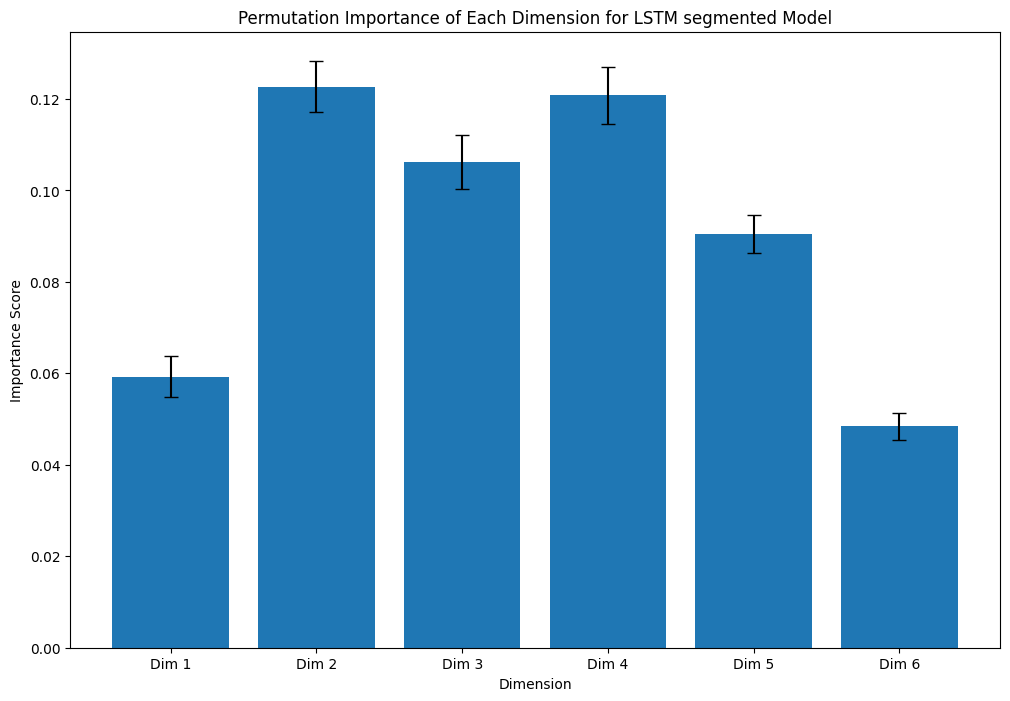

In [19]:
# Plot the permutation importance for the segmented LSTM model
importance_mean, importance_std, baseline_score, importance_scores = permutation_importance(lstm_segments, X_test_segments, y_test_segments)

plt.figure(figsize=(12,8))
plt.bar(range(len(importance_mean)), importance_mean, yerr=importance_std, capsize=5)
plt.xlabel('Dimension')
plt.ylabel('Importance Score')

plt.title('Permutation Importance of Each Dimension for the segmented LSTM Model')
plt.xticks(range(6), [f'Dim {i+1}' for i in range(len(importance_mean))])
plt.show()